# Avance 1 y 3 · EDA de los clientes de Chicago
### Proyecto Integrador M1 · *Conociendo al cliente 360°: datos, opiniones y tendencias*
**Autor:** Tomás Babot · **Empresa (caso):** InsightReach · **Rol:** Científico de Datos Junior

---

## Contexto
InsightReach es una empresa de marketing digital que crea campañas personalizadas para negocios locales. Para mejorar la efectividad de sus campañas necesita **segmentar mejor a sus clientes**. Recibimos una base de **30.000 clientes de restaurantes de 10 ciudades de EE. UU.** y debemos convertirla en información accionable.

## Qué resuelve este notebook
| Parte | Avance del proyecto | Secciones |
|---|---|---|
| **Avance #1** | Carga, filtrado por ciudad, limpieza y tabulación | 1 a 5 |
| **Análisis exploratorio** | Estadística descriptiva y visualizaciones | 6 y 7 |
| **Avance #3** | Análisis, interpretación y recomendaciones (usa los datos de Yelp) | 8 a 10 |

## Cómo ejecutarlo
Este notebook es **independiente**: se ejecuta de arriba hacia abajo (celda por celda con `Shift + Enter`, o todo junto con *Run All*). Lee dos archivos de la carpeta `data/` (la base de clientes y el CSV de restaurantes de Yelp) y guarda ahí sus resultados en CSV.

> Todas las rutas son relativas a la carpeta `Avances/`.

## 1. Preparar el entorno

**Qué hacemos:** importamos las librerías que vamos a usar.

**Por qué:** `pandas` y `numpy` manipulan los datos, `matplotlib` y `seaborn` los grafican y `scipy` nos da pruebas estadísticas.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')
plt.rcParams['text.parse_math'] = False   # para que el símbolo $ no se lea como una fórmula
pd.set_option('display.max_columns', None)

RUTA_DATA = Path('../data')
ORDEN_ESTRATO = ['Bajo', 'Medio', 'Alto', 'Muy Alto']   # el estrato tiene un orden lógico

## 2. Cargar y explorar la base de clientes  *(PI 1)*

**Qué hacemos:** leemos el CSV con `pd.read_csv` y revisamos su tamaño, tipos de dato y una muestra de filas.

**Por qué:** antes de limpiar hay que saber con qué estamos trabajando: cuántas filas y columnas hay, qué significa cada una y si los tipos de dato tienen sentido.

In [2]:
df_raw = pd.read_csv(RUTA_DATA / 'base_datos_restaurantes_USA_v2.csv')
print(f'Filas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]}')
df_raw.head()

Filas: 30,000 | Columnas: 17


,id_persona,nombre,apellido,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,telefono_contacto,correo_electronico,tipo_de_pago_mas_usado,ingresos_mensuales
0,2550327378,Jackson,Gomez,31.0,Masculino,Miami,Alto,6,67.51,Sí,No,Vegetariano,Sí,(830)220-1926,NaN,Efectivo,6425
1,9446112038,Samantha,Soto,40.0,Femenino,Denver,Medio,2,44.92,Sí,Sí,Mariscos,No,881-476-1426,NaN,Efectivo,2374
2,3098363243,Terry,Adams,62.0,Femenino,Denver,Bajo,2,9.24,Sí,Sí,Vegetariano,No,NaN,diana74@example.net,Efectivo,1110
3,4013002847,James,Shannon,41.0,Masculino,Boston,Alto,5,30.74,Sí,Sí,Carnes,Sí,NaN,scottfrey@example.com,Tarjeta,6931
4,7372911048,Susan,Jones,49.0,Femenino,San Diego,Bajo,0,0.00,No,No,Carnes,No,243.248.8919,glassgary@example.org,Tarjeta,1350


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_persona                 30000 non-null  int64  
 1   nombre                     30000 non-null  object 
 2   apellido                   30000 non-null  object 
 3   edad                       29899 non-null  float64
 4   genero                     30000 non-null  object 
 5   ciudad_residencia          30000 non-null  object 
 6   estrato_socioeconomico     30000 non-null  object 
 7   frecuencia_visita          30000 non-null  int64  
 8   promedio_gasto_comida      29855 non-null  float64
 9   ocio                       30000 non-null  object 
 10  consume_licor              30000 non-null  object 
 11  preferencias_alimenticias  28597 non-null  object 
 12  membresia_premium          30000 non-null  object 
 13  telefono_contacto          14834 non-null  obj

In [4]:
# Resumen estadístico automático de las columnas numéricas
df_raw.describe().round(2)

,id_persona,edad,frecuencia_visita,promedio_gasto_comida,ingresos_mensuales
count,3.000000e+04,29899.00,30000.00,29855.00,30000.00
mean,5.504765e+09,49.67,3.90,32.60,5389.76
std,2.602799e+09,23.84,2.74,26.40,4538.49
min,1.000153e+09,-5.00,-3.00,0.00,800.00
25%,3.243617e+09,33.00,2.00,13.29,1860.00
50%,5.515865e+09,49.00,4.00,25.51,3402.00
75%,7.754426e+09,65.00,5.00,44.40,7761.00
max,9.999627e+09,300.00,10.00,149.97,17999.00


**Diccionario de variables**

| Variable | Tipo | Significado |
|---|---|---|
| `id_persona` | identificador | Código único del cliente |
| `nombre`, `apellido`, `telefono_contacto`, `correo_electronico` | datos personales | Sirven para contactar, no para analizar |
| `edad` | numérica | Edad en años |
| `genero` | categórica | Femenino / Masculino |
| `ciudad_residencia` | categórica | Una de las 10 ciudades de la base |
| `estrato_socioeconomico` | categórica **ordinal** | Bajo < Medio < Alto < Muy Alto |
| `frecuencia_visita` | numérica | Cantidad de visitas a restaurantes (escala de 0 a 10) |
| `promedio_gasto_comida` | numérica | Gasto promedio por visita (USD) |
| `ocio`, `consume_licor`, `membresia_premium` | categóricas (Sí/No) | Hábitos y suscripción |
| `preferencias_alimenticias` | categórica | Carnes, Mariscos, Pescado, Vegetariano, Vegano u Otro |
| `tipo_de_pago_mas_usado` | categórica | Efectivo, Tarjeta, App o Criptomoneda |
| `ingresos_mensuales` | numérica | Ingreso mensual (USD) |

A simple vista ya aparecen señales de **problemas de calidad**: una `edad` mínima de -5 y máxima de 300, y una `frecuencia_visita` negativa. Los tratamos en la sección 4.

## 3. Filtrar la base por una ciudad específica  *(PI 2)*

**Qué hacemos:** contamos los clientes por ciudad y elegimos una para el análisis.

**Por qué:** las campañas de InsightReach son locales y cada ciudad tiene su propia oferta gastronómica, así que conviene analizar **una ciudad a la vez**. Además, en el Avance #2 vamos a cruzar los clientes con los restaurantes de Yelp de esa misma ciudad.

### 3.1 ¿Cómo se distribuyen las personas por ciudad?
Hay dos formas de contar cuántos clientes hay en cada ciudad. Primero con `value_counts()`, que cuenta cuántas veces aparece cada valor de la columna:

In [5]:
clientes_por_ciudad = df_raw['ciudad_residencia'].value_counts()
clientes_por_ciudad

ciudad_residencia
Chicago      5384
NYC          4769
Miami        3186
San Diego    3075
Dallas       2602
Boston       2547
Denver       2523
Houston      2212
Seattle      2191
Phoenix      1511
Name: count, dtype: int64

El resultado no es una tabla (`DataFrame`) sino una **`Series`**: una sola columna de valores con un índice (acá, el nombre de la ciudad). Lo comprobamos con `type()`:

In [6]:
type(clientes_por_ciudad)

pandas.core.series.Series

La segunda forma es **agrupar** por ciudad con `groupby` y contar los `id_persona` de cada grupo (cada persona tiene un `id_persona` único, así que contar ids es contar personas):

In [7]:
df_clientes_por_ciudad = df_raw.groupby('ciudad_residencia')['id_persona'].count()
df_clientes_por_ciudad

ciudad_residencia
Boston       2547
Chicago      5384
Dallas       2602
Denver       2523
Houston      2212
Miami        3186
NYC          4769
Phoenix      1511
San Diego    3075
Seattle      2191
Name: id_persona, dtype: int64

Las dos formas dan **los mismos números**; solo cambia el orden: `value_counts()` ordena de mayor a menor cantidad y `groupby` ordena alfabéticamente por ciudad. `groupby` es más flexible porque, además de contar, permite calcular otras cosas por grupo (promedios, sumas, etc.), algo que usamos más adelante.

Para trabajar cómodos, convertimos la `Series` en una **tabla** con `reset_index()` (el nombre de la ciudad pasa de ser el índice a ser una columna más) y le ponemos un nombre claro a la columna del conteo con `rename`:

In [8]:
df_clientes_por_ciudad = df_raw.groupby('ciudad_residencia')['id_persona'].count().reset_index()
df_clientes_por_ciudad = df_clientes_por_ciudad.rename(columns={'id_persona': 'cantidad_clientes'})
df_clientes_por_ciudad

,ciudad_residencia,cantidad_clientes
0,Boston,2547
1,Chicago,5384
2,Dallas,2602
3,Denver,2523
4,Houston,2212
5,Miami,3186
6,NYC,4769
7,Phoenix,1511
8,San Diego,3075
9,Seattle,2191


In [9]:
type(df_clientes_por_ciudad)   # ahora sí es un DataFrame (una tabla)

pandas.core.frame.DataFrame

### 3.2 Porcentaje de cada ciudad y gráfico

In [10]:
total_clientes = df_clientes_por_ciudad['cantidad_clientes'].sum()
df_clientes_por_ciudad['porcentaje'] = (df_clientes_por_ciudad['cantidad_clientes'] / total_clientes * 100).round(2)

# Ordenamos de la ciudad con más clientes a la que tiene menos
df_clientes_por_ciudad = df_clientes_por_ciudad.sort_values('cantidad_clientes', ascending=False)
df_clientes_por_ciudad

,ciudad_residencia,cantidad_clientes,porcentaje
1,Chicago,5384,17.95
6,NYC,4769,15.90
5,Miami,3186,10.62
8,San Diego,3075,10.25
2,Dallas,2602,8.67
0,Boston,2547,8.49
3,Denver,2523,8.41
4,Houston,2212,7.37
9,Seattle,2191,7.30
7,Phoenix,1511,5.04


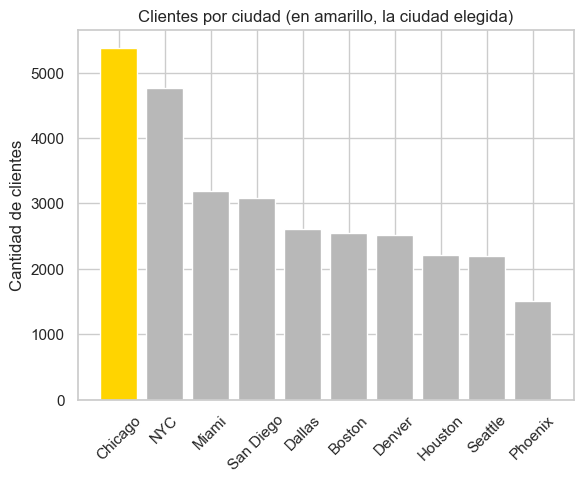

In [11]:
CIUDAD = 'Chicago'
colores = ['#ffd400' if ciudad == CIUDAD else '#b8b8b8' for ciudad in df_clientes_por_ciudad['ciudad_residencia']]

plt.bar(df_clientes_por_ciudad['ciudad_residencia'], df_clientes_por_ciudad['cantidad_clientes'], color=colores)
plt.title('Clientes por ciudad (en amarillo, la ciudad elegida)')
plt.ylabel('Cantidad de clientes')
plt.xticks(rotation=45)
plt.show()

### 3.3 Filtrar la ciudad elegida

In [12]:
df_ciudad = df_raw[df_raw['ciudad_residencia'] == CIUDAD].copy()
print(f'Clientes de {CIUDAD}: {len(df_ciudad):,} ({len(df_ciudad) / len(df_raw):.1%} de la base)')

Clientes de Chicago: 5,384 (17.9% de la base)


**Criterio de elección: Chicago.**
1. Es la ciudad con **más clientes** de la base (5.384, cerca del 18%), lo que da muestras más grandes y conclusiones más estables en cada segmento.
2. Tiene una oferta gastronómica muy amplia y bien documentada en Yelp, lo que enriquece el cruce del Avance #2.

Desde acá trabajamos siempre sobre `df_ciudad` y dejamos `df_raw` intacto para poder volver a los datos originales.

## 4. Limpieza de datos  *(PI 2)*

La limpieza sigue este orden: **detectar** los problemas (4.1 a 4.3), **tratarlos** con un criterio explícito (4.4) y **verificar** el resultado (4.5).

### 4.1 Valores nulos

In [13]:
nulos = pd.DataFrame({
    'nulos': df_ciudad.isnull().sum(),
    'porcentaje': (df_ciudad.isnull().mean() * 100).round(2),
})
nulos[nulos['nulos'] > 0].sort_values('nulos', ascending=False)

,nulos,porcentaje
telefono_contacto,2730,50.71
correo_electronico,2712,50.37
preferencias_alimenticias,268,4.98
promedio_gasto_comida,35,0.65
edad,23,0.43


**Interpretación:**
- `telefono_contacto` y `correo_electronico` tienen **~50% de nulos**. Como no aportan al análisis, no vale la pena imputarlos: los descartamos en 4.4.
- `preferencias_alimenticias` tiene 268 nulos (**5%**): es la única variable de comportamiento con faltantes relevantes.
- `promedio_gasto_comida` (35 casos, 0,65%) y `edad` (23 casos, 0,43%) tienen muy pocos nulos: se pueden imputar sin distorsionar los resultados.

### 4.2 Duplicados

In [14]:
print('Filas duplicadas exactas:              ', df_ciudad.duplicated().sum())
print('id_persona repetidos:                  ', df_ciudad['id_persona'].duplicated().sum())
print('Filas idénticas ignorando id_persona:  ', df_ciudad.drop(columns='id_persona').duplicated().sum())
print('Correos repetidos (sin contar nulos):  ', df_ciudad['correo_electronico'].dropna().duplicated().sum())

Filas duplicadas exactas:               0
id_persona repetidos:                   0
Filas idénticas ignorando id_persona:   0
Correos repetidos (sin contar nulos):   14


In [15]:
# Posibles homónimos: mismo nombre, apellido y edad
repetidos = df_ciudad.duplicated(subset=['nombre', 'apellido', 'edad'], keep=False)
df_ciudad[repetidos].sort_values(['apellido', 'nombre'])[['id_persona', 'nombre', 'apellido', 'edad', 'genero',
                                                          'estrato_socioeconomico', 'ingresos_mensuales']]

,id_persona,nombre,apellido,edad,genero,estrato_socioeconomico,ingresos_mensuales
5893,9411532909,William,Gibson,34.0,Masculino,Bajo,1027
11496,3925995469,William,Gibson,34.0,Masculino,Alto,6567
151,9954587710,Matthew,Martinez,63.0,Masculino,Alto,6006
14565,5449634185,Matthew,Martinez,63.0,Masculino,Medio,2070
6477,8581299821,Robert,Smith,58.0,Masculino,Alto,5526
19544,3190453309,Robert,Smith,58.0,Masculino,Medio,2511


**Interpretación:**
- **No hay duplicados que eliminar**: no existen filas repetidas, `id_persona` es único y no hay filas idénticas si ignoramos el identificador.
- Aparecen **3 pares de homónimos** (mismo nombre, apellido, edad y género), pero tienen distinto `id_persona`, estrato e ingresos: son **personas diferentes**, no registros duplicados.
- Hay **14 correos repetidos** entre clientes con distinto `id_persona` y datos distintos. Como el correo no se usa en el análisis, no afecta los resultados, pero conviene informarlo como problema de calidad del origen de datos.

### 4.3 Errores y valores imposibles

In [16]:
print('Edades menores a 18 o mayores a 100:  ', ((df_ciudad['edad'] < 18) | (df_ciudad['edad'] > 100)).sum())
print('Frecuencias de visita negativas:      ', (df_ciudad['frecuencia_visita'] < 0).sum())
print('Gastos negativos:                     ', (df_ciudad['promedio_gasto_comida'] < 0).sum())
print('Ingresos menores o iguales a 0:       ', (df_ciudad['ingresos_mensuales'] <= 0).sum())

Edades menores a 18 o mayores a 100:   29
Frecuencias de visita negativas:       286
Gastos negativos:                      0
Ingresos menores o iguales a 0:        0


In [17]:
# ¿Qué valores tienen esas edades imposibles?
edades_raras = df_ciudad[(df_ciudad['edad'] < 18) | (df_ciudad['edad'] > 100)]
edades_raras['edad'].value_counts()

edad
-5.0      16
 300.0    13
Name: count, dtype: int64

In [18]:
# Distribución de frecuencia_visita (¿hay valores raros?)
df_ciudad['frecuencia_visita'].value_counts().sort_index()

frecuencia_visita
-3      286
 0      261
 1      273
 2      649
 3      715
 4      921
 5     1059
 6      642
 7      164
 8      124
 9      141
 10     149
Name: count, dtype: int64

In [19]:
# ¿El gasto 0 es un error? Lo comparamos con la frecuencia de visita 0.
pd.crosstab(df_ciudad['frecuencia_visita'] == 0, df_ciudad['promedio_gasto_comida'] == 0,
            rownames=['frecuencia_visita == 0'], colnames=['gasto == 0'])

gasto == 0,False,True
frecuencia_visita == 0,,
False,5123,0
True,0,261


**Interpretación:**
- **`edad`:** 29 clientes tienen valores imposibles: **-5** y **300**. Son errores de carga.
- **`frecuencia_visita`:** 286 clientes tienen **-3**. Una frecuencia negativa no existe: es un código de error o un valor centinela.
- **`promedio_gasto_comida` igual a 0 no es un error:** los 261 clientes con gasto 0 son **exactamente** los 261 con `frecuencia_visita == 0`. Son clientes que no visitan restaurantes, y su gasto es 0 de forma coherente. Los conservamos.
- Ingresos y gasto no tienen valores negativos.

**Chequeo adicional de valores atípicos (outliers) con la regla del IQR**, solo para informar (no se eliminan). Un valor es atípico si queda por debajo de `Q1 - 1.5 × IQR` o por encima de `Q3 + 1.5 × IQR`:

In [20]:
columnas_numericas = ['edad', 'frecuencia_visita', 'promedio_gasto_comida', 'ingresos_mensuales']

filas = []
for col in columnas_numericas:
    q1 = df_ciudad[col].quantile(0.25)
    q3 = df_ciudad[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    atipicos = ((df_ciudad[col] < limite_inferior) | (df_ciudad[col] > limite_superior)).sum()
    filas.append({'variable': col, 'limite_inferior': limite_inferior, 'limite_superior': limite_superior, 'outliers': atipicos})

pd.DataFrame(filas).round(2)

,variable,limite_inferior,limite_superior,outliers
0,edad,-15.00,113.00,13
1,frecuencia_visita,-2.50,9.50,435
2,promedio_gasto_comida,-30.56,74.16,264
3,ingresos_mensuales,-6612.62,15870.38,228


**Interpretación:**
- En `edad` la regla del IQR detecta solo los 13 valores de **300**, pero **no detecta los -5**, porque su límite inferior (-15) es demasiado amplio. Por eso no alcanza con una regla estadística: también hace falta una **regla de dominio** (edad entre 18 y 100).
- En `frecuencia_visita` los 435 "outliers" son 286 errores (-3) más 149 clientes que visitan 10 veces, un valor **legítimo**.
- En `promedio_gasto_comida` (264) e `ingresos_mensuales` (228) los valores altos son **clientes reales de alto poder adquisitivo**, no errores. **No se eliminan**: son justamente los clientes más valiosos para el negocio.

### 4.4 Tratamiento

| Problema | Decisión | Justificación |
|---|---|---|
| `edad` fuera de 18-100 o nula | Pasa a `NaN` y se rellena con la **mediana** | Son errores de carga (-5 y 300). La mediana es robusta a valores extremos. |
| `frecuencia_visita` negativa | Pasa a `NaN` y se rellena con la **mediana** | Una frecuencia negativa es imposible. |
| `promedio_gasto_comida` nulo | Se rellena con la **mediana** | Pocos casos y distribución asimétrica: la mediana representa mejor al cliente típico. |
| `preferencias_alimenticias` nula | Categoría explícita **`'Sin dato'`** | No inventamos una preferencia y evitamos que los gráficos oculten estos clientes sin avisar. |
| Gasto igual a 0 | **Se conserva** | Coincide exactamente con `frecuencia_visita == 0`: son clientes que no visitan, no un error. |
| `nombre`, `apellido`, `telefono_contacto`, `correo_electronico` | Se **eliminan** de la base de trabajo | No aportan al análisis (teléfono y correo tienen ~50% de nulos) y protegen datos personales al publicar el repositorio. |
| Duplicados | No hay que eliminar nada | Ver 4.2. |

Trabajamos sobre una copia (`df_limpio`) para no tocar `df_ciudad`:

In [21]:
df_limpio = df_ciudad.copy()

In [22]:
# Paso 1: los errores pasan a ser nulos (NaN)
df_limpio.loc[(df_limpio['edad'] < 18) | (df_limpio['edad'] > 100), 'edad'] = np.nan
df_limpio.loc[df_limpio['frecuencia_visita'] < 0, 'frecuencia_visita'] = np.nan

In [23]:
# Paso 2: los nulos se rellenan con la mediana de cada columna
df_limpio['edad'] = df_limpio['edad'].fillna(df_limpio['edad'].median())
df_limpio['frecuencia_visita'] = df_limpio['frecuencia_visita'].fillna(df_limpio['frecuencia_visita'].median())
df_limpio['promedio_gasto_comida'] = df_limpio['promedio_gasto_comida'].fillna(df_limpio['promedio_gasto_comida'].median())

In [24]:
# Paso 3: la preferencia faltante pasa a ser una categoría explícita
df_limpio['preferencias_alimenticias'] = df_limpio['preferencias_alimenticias'].fillna('Sin dato')

In [25]:
# Paso 4: sacamos los datos personales
df_limpio = df_limpio.drop(columns=['nombre', 'apellido', 'telefono_contacto', 'correo_electronico'])

In [26]:
# Paso 5: edad y frecuencia son números enteros (habían quedado con decimales por los nulos)
df_limpio['edad'] = df_limpio['edad'].astype(int)
df_limpio['frecuencia_visita'] = df_limpio['frecuencia_visita'].astype(int)

### 4.5 Verificación del resultado

In [27]:
print('Nulos restantes:', df_limpio.isnull().sum().sum())
print('Filas:', len(df_limpio), '| Columnas:', df_limpio.shape[1])

Nulos restantes: 0
Filas: 5384 | Columnas: 13


In [28]:
# Comparamos antes y después de la limpieza
antes_despues = pd.DataFrame({
    'antes_min': df_ciudad[columnas_numericas].min(), 'despues_min': df_limpio[columnas_numericas].min(),
    'antes_max': df_ciudad[columnas_numericas].max(), 'despues_max': df_limpio[columnas_numericas].max(),
    'antes_media': df_ciudad[columnas_numericas].mean().round(2), 'despues_media': df_limpio[columnas_numericas].mean().round(2),
})
antes_despues

,antes_min,despues_min,antes_max,despues_max,antes_media,despues_media
edad,-5.0,18.0,300.00,80.00,49.18,48.73
frecuencia_visita,-3.0,0.0,10.00,10.00,3.82,4.20
promedio_gasto_comida,0.0,0.0,104.92,104.92,25.53,25.49
ingresos_mensuales,801.0,801.0,17999.00,17999.00,5202.31,5202.31


In [29]:
# Tipos de dato antes y después
tipos = pd.DataFrame({'antes': df_ciudad.dtypes.astype(str), 'despues': df_limpio.dtypes.astype(str)})
tipos.loc[df_limpio.columns].T

,id_persona,edad,genero,ciudad_residencia,estrato_socioeconomico,frecuencia_visita,promedio_gasto_comida,ocio,consume_licor,preferencias_alimenticias,membresia_premium,tipo_de_pago_mas_usado,ingresos_mensuales
antes,int64,float64,object,object,object,int64,float64,object,object,object,object,object,int64
despues,int64,int64,object,object,object,int64,float64,object,object,object,object,object,int64


**Interpretación:**
- La base queda **sin nulos**, con 5.384 clientes y 13 columnas (se eliminaron las 4 de datos personales).
- Los rangos son ahora válidos: `edad` entre 18 y 80 y `frecuencia_visita` entre 0 y 10.
- **Tipos de dato:** `edad` pasa de decimal (`float64`, porque tenía nulos) a entero (`int64`); los identificadores y las variables numéricas quedan numéricas y las de texto (`object`) no necesitan conversión para este análisis.
- La limpieza casi no altera las medias: `edad` pasa de 49,18 a 48,73 y el gasto de 25,53 a 25,49. La media de `frecuencia_visita` sube de 3,82 a 4,20 porque desaparecen los -3 que la estaban tirando hacia abajo.

## 5. Tabulación: distribución de las variables  *(PI 3)*

**Qué hacemos:** armamos tablas de frecuencia (cantidad y porcentaje) de las variables categóricas y cruzamos algunas de a pares.

**Por qué:** para variables que no son números no tiene sentido calcular una media; se resumen contando cuántos clientes hay en cada categoría.

In [30]:
columnas_categoricas = ['genero', 'preferencias_alimenticias', 'consume_licor', 'estrato_socioeconomico',
                        'ocio', 'membresia_premium', 'tipo_de_pago_mas_usado']

for col in columnas_categoricas:
    print(f'--- {col} ---')
    tabla = pd.DataFrame({
        'conteo': df_limpio[col].value_counts(),
        'porcentaje': (df_limpio[col].value_counts(normalize=True) * 100).round(2),
    })
    display(tabla)

--- genero ---


,conteo,porcentaje
genero,,
Masculino,2716,50.45
Femenino,2668,49.55


--- preferencias_alimenticias ---


,conteo,porcentaje
preferencias_alimenticias,,
Carnes,1589,29.51
Vegetariano,1123,20.86
Mariscos,696,12.93
Otro,591,10.98
Vegano,571,10.61
Pescado,546,10.14
Sin dato,268,4.98


--- consume_licor ---


...

,conteo,porcentaje
ocio,,
No,2712,50.37
Sí,2672,49.63


--- membresia_premium ---


,conteo,porcentaje
membresia_premium,,
No,3169,58.86
Sí,2215,41.14


--- tipo_de_pago_mas_usado ---


,conteo,porcentaje
tipo_de_pago_mas_usado,,
Efectivo,2120,39.38
Tarjeta,1790,33.25
App,1375,25.54
Criptomoneda,99,1.84


**Interpretación:**
- **Preferencias:** *Carnes* es la preferencia individual más frecuente (29,5%), pero si sumamos **Vegetariano (20,9%) y Vegano (10,6%)** llegamos al **31,5%**: el grupo más grande de todos. Mariscos y pescado juntos suman 23%.
- **Perfil general:** género equilibrado (50/50), el 62,7% consume licor y el 41% tiene membresía premium.
- **Pagos:** el **efectivo sigue siendo el medio principal (39%)**, seguido de tarjeta (33%) y app (26%). La criptomoneda es marginal (1,8%).
- **Estratos:** el estrato Medio es el más grande (33%) y el Muy Alto el más chico (17%).

### Tablas cruzadas (porcentaje dentro de cada fila)

In [31]:
# Consumo de licor según estrato socioeconómico (%)
pd.crosstab(df_limpio['estrato_socioeconomico'], df_limpio['consume_licor'], normalize='index').mul(100).round(1).reindex(ORDEN_ESTRATO)

consume_licor,No,Sí
estrato_socioeconomico,,
Bajo,38.3,61.7
Medio,36.6,63.4
Alto,36.8,63.2
Muy Alto,38.3,61.7


In [32]:
# Preferencia alimenticia según género (%)
pd.crosstab(df_limpio['genero'], df_limpio['preferencias_alimenticias'], normalize='index').mul(100).round(1)

preferencias_alimenticias,Carnes,Mariscos,Otro,Pescado,Sin dato,Vegano,Vegetariano
genero,,,,,,,
Femenino,29.9,12.6,10.5,9.8,5.3,10.7,21.2
Masculino,29.2,13.3,11.5,10.5,4.6,10.5,20.5


In [33]:
# Membresía premium según estrato socioeconómico (%)
pd.crosstab(df_limpio['estrato_socioeconomico'], df_limpio['membresia_premium'], normalize='index').mul(100).round(1).reindex(ORDEN_ESTRATO)

membresia_premium,No,Sí
estrato_socioeconomico,,
Bajo,99.3,0.7
Medio,86.9,13.1
Alto,27.9,72.1
Muy Alto,4.7,95.3


**Interpretación:**
- **El consumo de licor no depende del estrato:** en los cuatro estratos ronda el 62-63%. La prueba de chi-cuadrado (sección 8) confirma que la diferencia no es significativa.
- **La preferencia alimenticia es casi igual entre géneros** (las diferencias son de 1 punto o menos).
- **La membresía premium sí depende mucho del estrato:** pasa de **0,7% en el estrato Bajo a 95,3% en el Muy Alto**. La membresía es, en la práctica, un reflejo del nivel socioeconómico. Esto es clave para no sacar conclusiones equivocadas más adelante (ver P1).

## 6. Estadística descriptiva

**Qué hacemos:** resumimos cada variable numérica con medidas de **tendencia central** (dónde está el valor típico), **dispersión** (qué tan esparcidos están los datos) y **forma** (asimetría y curtosis).

**Por qué:** la media sola no alcanza. Si media y mediana difieren mucho, o el desvío es grande respecto de la media, hay asimetría o valores extremos que cambian cómo debemos interpretar la variable.

In [34]:
# .agg() calcula varias medidas de una vez; .T da vuelta la tabla para leerla mejor
resumen = df_limpio[columnas_numericas].agg(['mean', 'median', 'std', 'min', 'max', 'skew', 'kurt']).T
resumen.columns = ['media', 'mediana', 'desvio_std', 'minimo', 'maximo', 'asimetria', 'curtosis']

resumen['moda'] = df_limpio[columnas_numericas].mode().iloc[0]
resumen['iqr'] = df_limpio[columnas_numericas].quantile(0.75) - df_limpio[columnas_numericas].quantile(0.25)
resumen['coef_variacion_%'] = resumen['desvio_std'] / resumen['media'] * 100

resumen.round(2)

,media,mediana,desvio_std,minimo,maximo,asimetria,curtosis,moda,iqr,coef_variacion_%
edad,48.73,49.00,18.05,18.0,80.00,0.02,-1.19,49.0,31.00,37.04
frecuencia_visita,4.20,4.00,2.19,0.0,10.00,0.41,0.37,4.0,2.00,52.09
promedio_gasto_comida,25.49,19.04,22.01,0.0,104.92,1.40,1.63,0.0,25.89,86.36
ingresos_mensuales,5202.31,3244.50,4514.16,801.0,17999.00,1.25,0.53,1267.0,5620.75,86.77


In [35]:
# Percentiles
df_limpio[columnas_numericas].quantile([0.10, 0.25, 0.50, 0.75, 0.90]).round(2)

,edad,frecuencia_visita,promedio_gasto_comida,ingresos_mensuales
0.10,24.0,2.0,6.02,1167.00
0.25,33.0,3.0,8.74,1818.50
0.50,49.0,4.0,19.04,3244.50
0.75,64.0,5.0,34.63,7439.25
0.90,74.0,7.0,56.32,13052.00


**Interpretación:**
- **`edad`:** media (48,7) y mediana (49) casi iguales, asimetría ≈ 0 y curtosis negativa (-1,19): la distribución es **plana**, con clientes repartidos de forma pareja entre 18 y 80 años.
- **`frecuencia_visita`:** simétrica, con media 4,2 y mediana 4. La mayoría visita entre 3 y 5 veces (IQR = 2).
- **`promedio_gasto_comida`:** **asimétrica hacia la derecha** (asimetría 1,40): la media ($25,49) supera bastante a la mediana ($19,04) porque unos pocos clientes gastan mucho. El coeficiente de variación (86%) indica gran heterogeneidad. La moda es 0 por los 261 clientes que no visitan.
- **`ingresos_mensuales`:** también asimétrica a la derecha (1,25): media $5.202 vs. mediana $3.244 y coeficiente de variación de 87%. Hay mucha desigualdad de ingresos entre clientes.
- Como gasto e ingresos son asimétricos, para describir al cliente típico conviene usar la **mediana** y no la media.

## 7. Análisis exploratorio con visualizaciones

### 7.1 Distribución de cada variable numérica (histogramas)

**Cómo leerlo:** cada barra cuenta cuántos clientes caen en ese intervalo; la curva es una versión suavizada (KDE). La línea roja es la **media** y la verde, la **mediana**: si están lejos una de la otra, la distribución es asimétrica.

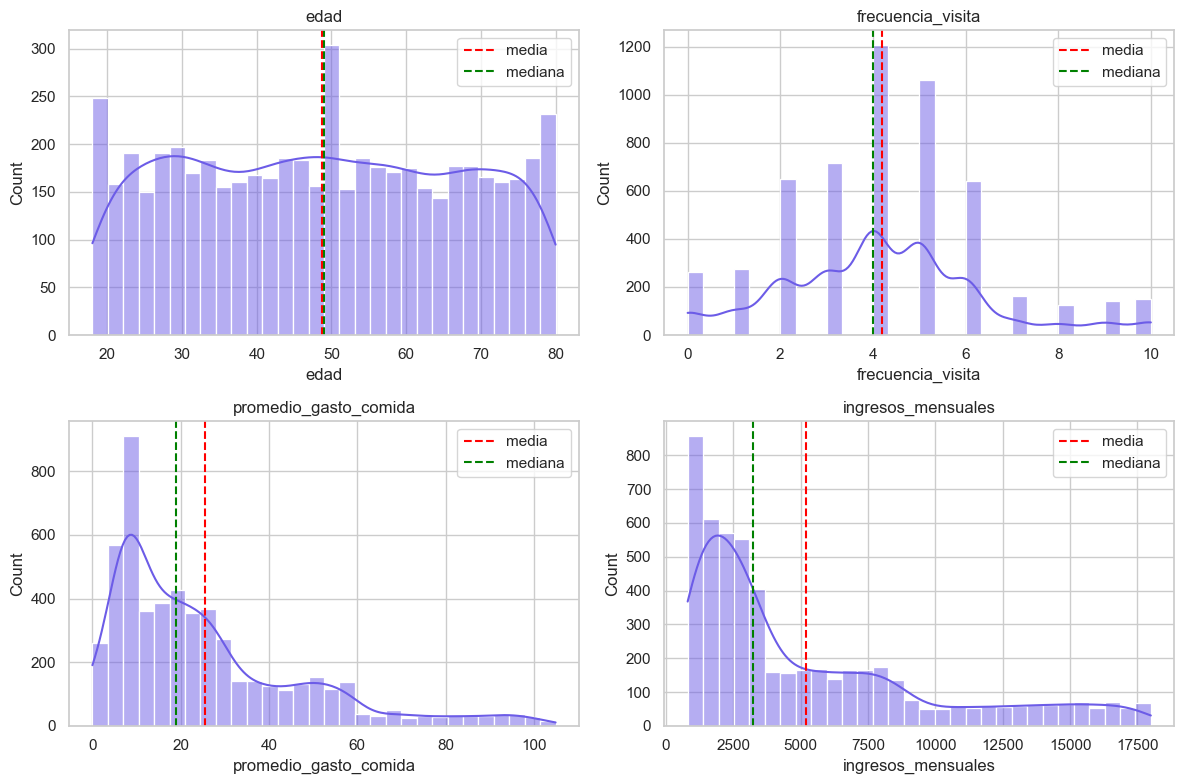

In [36]:
fig, ejes = plt.subplots(2, 2, figsize=(12, 8))   # una grilla de 2 filas x 2 columnas
ejes = ejes.flatten()                             # la convertimos en una lista simple de 4 gráficos

for i, col in enumerate(columnas_numericas):
    sns.histplot(df_limpio[col], bins=30, kde=True, ax=ejes[i], color='#6c5ce7')
    ejes[i].axvline(df_limpio[col].mean(), color='red', linestyle='--', label='media')
    ejes[i].axvline(df_limpio[col].median(), color='green', linestyle='--', label='mediana')
    ejes[i].set_title(col)
    ejes[i].legend()

plt.tight_layout()
plt.show()

**Interpretación:**
- `edad` es prácticamente **uniforme** entre 18 y 80 años, sin un grupo etario dominante.
- `frecuencia_visita` tiene forma de campana centrada en 4-5 visitas, con un pequeño grupo de clientes muy frecuentes (10 visitas).
- `promedio_gasto_comida` e `ingresos_mensuales` tienen una **cola larga a la derecha**: la línea roja (media) queda a la derecha de la verde (mediana). Hay además un pico de gasto en 0 (los clientes que no visitan).

### 7.2 Variables categóricas (countplots)

**Cómo leerlo:** la altura de cada barra es la cantidad de clientes de esa categoría. Ordenamos de mayor a menor, salvo el estrato, que tiene un orden lógico propio.

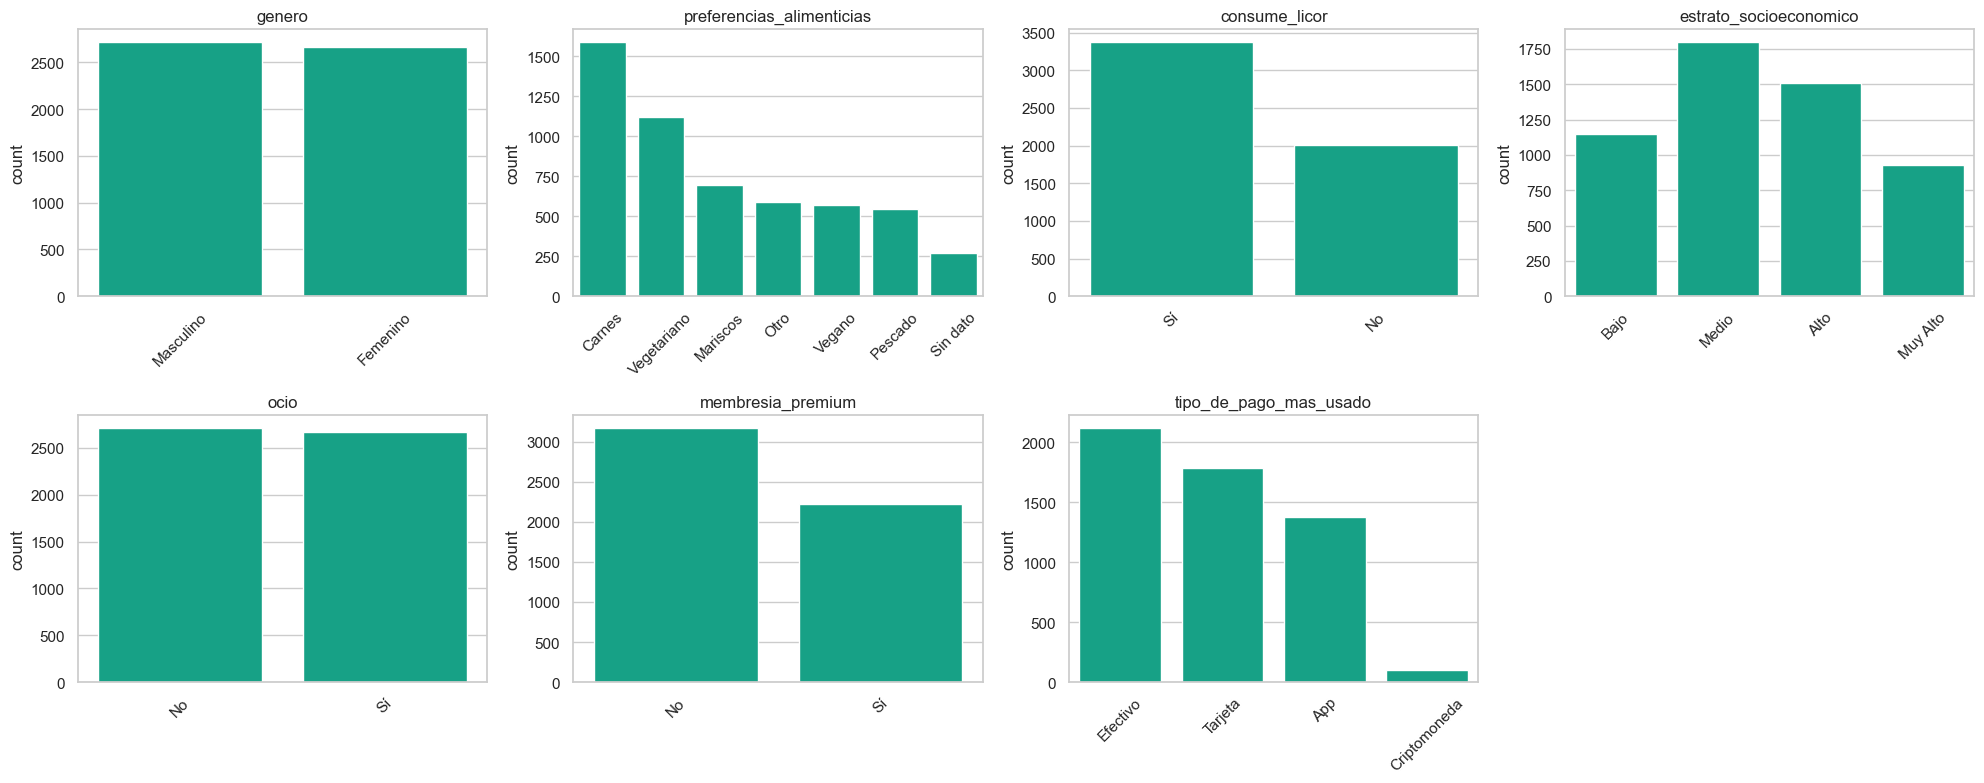

In [37]:
fig, ejes = plt.subplots(2, 4, figsize=(20, 8))
ejes = ejes.flatten()

for i, col in enumerate(columnas_categoricas):
    if col == 'estrato_socioeconomico':
        orden = ORDEN_ESTRATO                            # orden lógico
    else:
        orden = df_limpio[col].value_counts().index      # de mayor a menor
    sns.countplot(data=df_limpio, x=col, order=orden, ax=ejes[i], color='#00b894')
    ejes[i].set_title(col)
    ejes[i].tick_params(axis='x', rotation=45)
    ejes[i].set_xlabel('')

ejes[-1].axis('off')   # el último cuadro queda vacío
plt.tight_layout()
plt.show()

**Interpretación:** confirma lo visto en las tablas: género y ocio están equilibrados, *Carnes* lidera entre las preferencias individuales, el efectivo es el medio de pago más usado y el estrato Medio es el más numeroso. La criptomoneda y el estrato Muy Alto son las categorías más chicas.

### 7.3 Detección de outliers (boxplots)

**Cómo leerlo:** la caja va del percentil 25 al 75, la línea central es la mediana y los puntos fuera de los bigotes son valores atípicos.

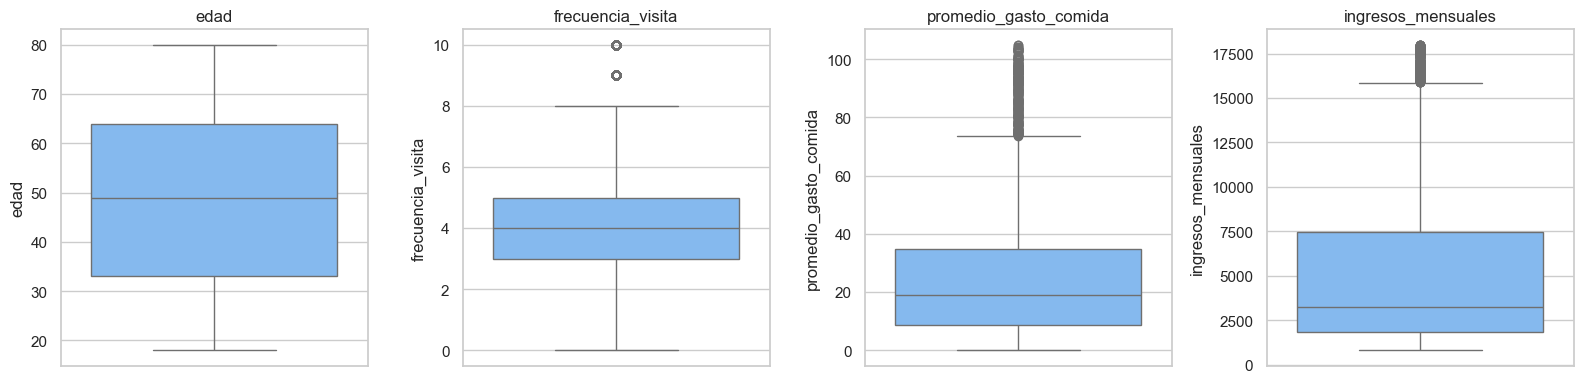

In [38]:
fig, ejes = plt.subplots(1, 4, figsize=(16, 4))

for i, col in enumerate(columnas_numericas):
    sns.boxplot(y=df_limpio[col], ax=ejes[i], color='#74b9ff')
    ejes[i].set_title(col)

plt.tight_layout()
plt.show()

**Interpretación:**
- `edad` no muestra outliers una vez limpiada.
- En `promedio_gasto_comida` e `ingresos_mensuales` hay muchos puntos por encima del bigote superior: son clientes de **alto gasto e ingresos**, valores legítimos que conservamos.
- En `frecuencia_visita` los valores 9 y 10 quedan marcados como atípicos, aunque son plenamente posibles.

### 7.4 Correlación entre variables numéricas

**Cómo leerlo:** cada celda va de -1 (relación inversa) a 1 (relación directa); cerca de 0 significa que no hay relación **lineal**.

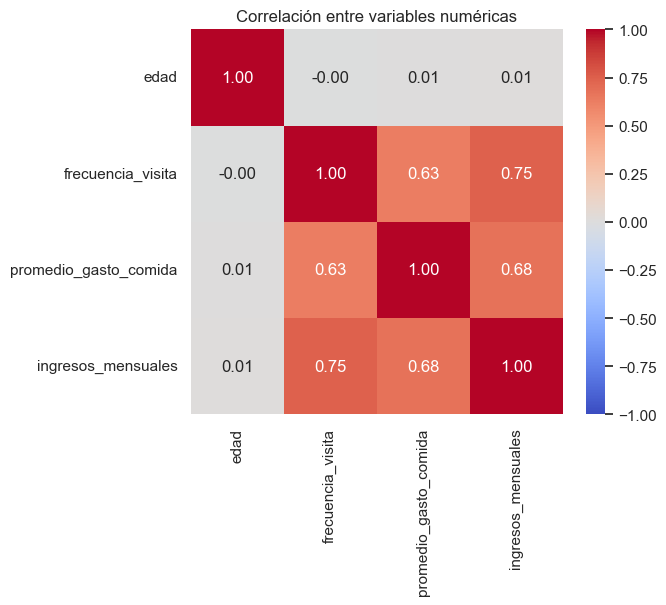

In [39]:
plt.figure(figsize=(6, 5))
sns.heatmap(df_limpio[columnas_numericas].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlación entre variables numéricas')
plt.show()

**Interpretación:**
- **`ingresos_mensuales` es la variable que más se relaciona con el comportamiento:** correlación de **0,75 con la frecuencia de visita** y **0,68 con el gasto**. Cuanto más ganan, más visitan y más gastan.
- `frecuencia_visita` y `promedio_gasto_comida` también van de la mano (**0,63**).
- **`edad` no se relaciona con el gasto, la frecuencia ni los ingresos** (correlaciones de 0,00 a 0,01). Más adelante (P4) veremos que la edad sí importa para otra cosa: el consumo de licor.
- Correlación no implica causalidad: acá los ingresos y el estrato están detrás de casi todo.

### 7.5 Ingresos vs. gasto en comida (scatterplot)

**Cómo leerlo:** cada punto es un cliente. Coloreamos por estrato para ver si los grupos se separan.

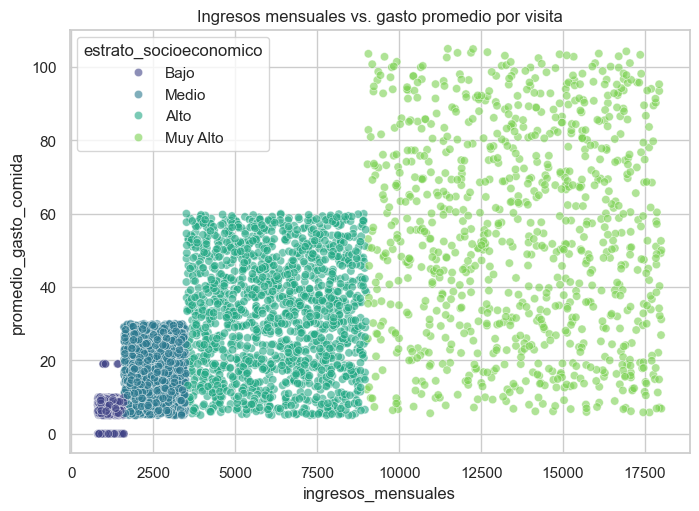

In [40]:
plt.figure(figsize=(8, 5.5))
sns.scatterplot(data=df_limpio, x='ingresos_mensuales', y='promedio_gasto_comida',
                hue='estrato_socioeconomico', hue_order=ORDEN_ESTRATO, alpha=0.6, palette='viridis')
plt.title('Ingresos mensuales vs. gasto promedio por visita')
plt.show()

**Interpretación:** hay una relación positiva clara: a mayores ingresos, mayor gasto por visita. Los colores muestran que los **estratos forman franjas**: Bajo y Medio ocupan la zona de bajos ingresos y bajo gasto, y Alto y Muy Alto la de ingresos y gasto altos. La dispersión del gasto crece a medida que aumentan los ingresos.

### 7.6 Gasto según estrato y según preferencia alimenticia

**Cómo leerlo:** comparamos el gasto entre grupos; el boxplot muestra la distribución y las barras, el promedio.

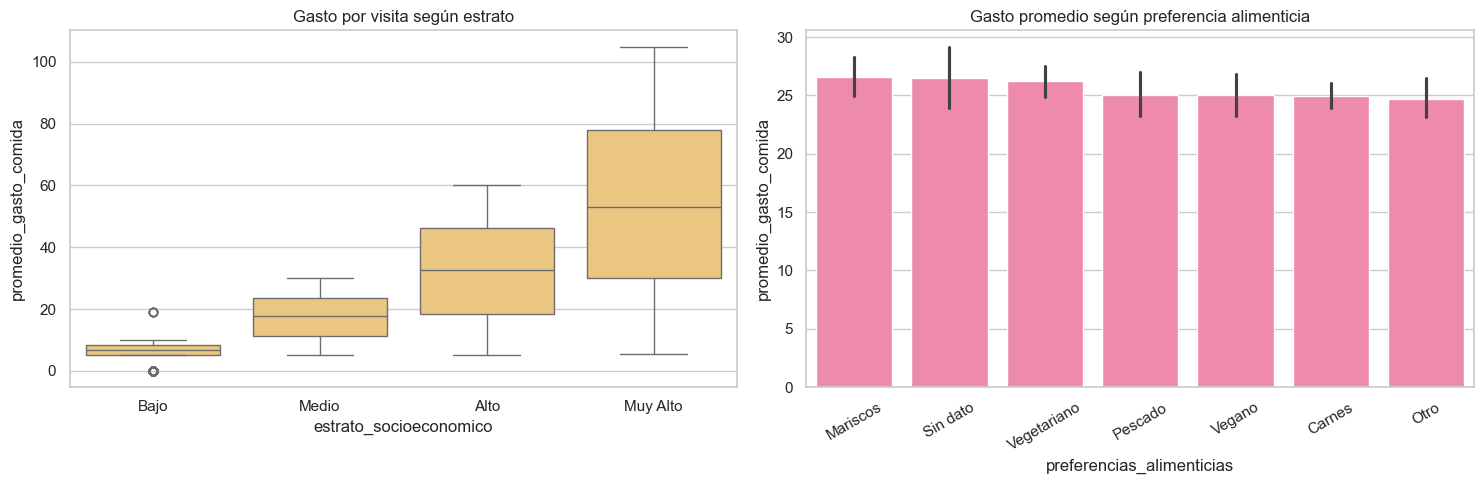

In [41]:
fig, ejes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=df_limpio, x='estrato_socioeconomico', y='promedio_gasto_comida', order=ORDEN_ESTRATO,
            ax=ejes[0], color='#fdcb6e')
ejes[0].set_title('Gasto por visita según estrato')

orden_pref = df_limpio.groupby('preferencias_alimenticias')['promedio_gasto_comida'].mean().sort_values(ascending=False).index
sns.barplot(data=df_limpio, x='preferencias_alimenticias', y='promedio_gasto_comida', order=orden_pref,
            ax=ejes[1], color='#fd79a8')
ejes[1].set_title('Gasto promedio según preferencia alimenticia')
ejes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**Interpretación:**
- **El estrato determina el gasto:** la mediana por visita sube de **$6,86 (Bajo)** a **$17,61 (Medio)**, **$32,58 (Alto)** y **$53,09 (Muy Alto)**. El estrato Muy Alto gasta casi 8 veces más que el Bajo.
- **La preferencia alimenticia casi no cambia el gasto:** todos los grupos gastan entre $24,7 y $26,6 en promedio. Lo que un cliente **quiere comer** y lo que **puede gastar** son dimensiones independientes, y por eso conviene segmentar por ambas.

## 8. Análisis e interpretación de hallazgos  *(Avance #3)*

Ahora sumamos los datos de **Yelp** (la conexión con la API y la integración se explican paso a paso en `Avance_API_Yelp.ipynb`) para responder **preguntas de negocio** que ayuden a InsightReach a segmentar y diseñar campañas.

| # | Pregunta de negocio |
|---|---|
| P1 | ¿Qué características distinguen a los clientes que más gastan? |
| P2 | ¿La preferencia alimenticia se relaciona con el estrato socioeconómico? |
| P3 | ¿Qué otras variables están relacionadas entre sí? *(mapa de asociaciones)* |
| P4 | ¿Quién consume licor? |
| P5 | ¿La oferta de Chicago cubre lo que los clientes **prefieren comer**? |
| P6 | ¿La oferta de Chicago cubre lo que los clientes **pueden pagar**? |
| P7 | ¿Cómo segmentamos a los clientes según su valor y cómo es cada segmento? |
| P8 | ¿Dónde está el potencial de crecimiento? |

### 8.0 Preparar los datos de Yelp y agrupar las preferencias
Leemos los restaurantes de Yelp (el CSV que guarda `Avance_API_Yelp.ipynb`) y los agrupamos por tipo de comida, igual que en ese notebook, para poder compararlos con lo que prefieren los clientes.

In [42]:
# Restaurantes de Yelp (CSV guardado con la respuesta de la API)
df_yelp = pd.read_csv(RUTA_DATA / 'yelp_restaurantes_chicago.csv')

# ¿A qué grupo de comida pertenece cada restaurante? (True / False)
df_yelp['carnes'] = df_yelp['aliases'].str.contains('steak|bbq|burgers|hotdog|chicken_wings|chickenshop|butcher')
df_yelp['mariscos_pescado'] = df_yelp['aliases'].str.contains('seafood|sushi|fishnchips|poke')
df_yelp['vegetariano_vegano'] = df_yelp['aliases'].str.contains('vegetarian|vegan')
df_yelp['otro'] = ~(df_yelp['carnes'] | df_yelp['mariscos_pescado'] | df_yelp['vegetariano_vegano'])

In [43]:
# Las preferencias de los clientes, agrupadas igual que los restaurantes
grupos = {'Carnes': 'Carnes', 'Mariscos': 'Mariscos y pescado', 'Pescado': 'Mariscos y pescado',
          'Vegetariano': 'Vegetariano/Vegano', 'Vegano': 'Vegetariano/Vegano', 'Otro': 'Otro', 'Sin dato': 'Sin dato'}

df_int = df_limpio.copy()
df_int['grupo_preferencia'] = df_int['preferencias_alimenticias'].map(grupos)

# Grupos de edad (los usamos más adelante)
df_int['grupo_edad'] = pd.cut(df_int['edad'], bins=[17, 30, 50, 70, 100], labels=['18-30', '31-50', '51-70', '71+'])

df_int['grupo_preferencia'].value_counts()

grupo_preferencia
Vegetariano/Vegano    1694
Carnes                1589
Mariscos y pescado    1242
Otro                   591
Sin dato               268
Name: count, dtype: int64

### P1 · ¿Qué características distinguen a los clientes que más gastan?

Comparamos el gasto promedio por visita entre grupos y verificamos con una prueba estadística si las diferencias son reales o podrían ser azar. Usamos la prueba de **Kruskal-Wallis** (sirve para comparar dos o más grupos y no exige que el gasto tenga forma de campana). Si el **p-valor es menor a 0,05**, la diferencia entre grupos es significativa.

In [44]:
variables = ['estrato_socioeconomico', 'membresia_premium', 'consume_licor', 'ocio',
             'genero', 'tipo_de_pago_mas_usado', 'preferencias_alimenticias', 'grupo_edad']

filas = []
for variable in variables:
    # una lista con el gasto de cada grupo (por ejemplo, uno por estrato)
    gasto_por_grupo = [datos for nombre, datos in df_int.groupby(variable, observed=True)['promedio_gasto_comida']]
    p_valor = stats.kruskal(*gasto_por_grupo).pvalue

    medianas = df_int.groupby(variable, observed=True)['promedio_gasto_comida'].median()
    filas.append({'variable': variable, 'p_valor': p_valor,
                  'grupo_que_mas_gasta': medianas.idxmax(), 'mediana_mayor': medianas.max(),
                  'grupo_que_menos_gasta': medianas.idxmin(), 'mediana_menor': medianas.min()})

resultados_p1 = pd.DataFrame(filas).sort_values('p_valor')
resultados_p1['diferencia_significativa'] = np.where(resultados_p1['p_valor'] < 0.05, 'Sí', 'No')
resultados_p1['p_valor'] = resultados_p1['p_valor'].round(4)   # 0.0 significa "menor a 0.0001"
resultados_p1

,variable,p_valor,grupo_que_mas_gasta,mediana_mayor,grupo_que_menos_gasta,mediana_menor,diferencia_significativa
0,estrato_socioeconomico,0.0000,Muy Alto,53.090,Bajo,6.855,Sí
1,membresia_premium,0.0000,Sí,35.090,No,11.240,Sí
3,ocio,0.2957,Sí,19.190,No,18.915,No
6,preferencias_alimenticias,0.5028,Mariscos,20.325,Carnes,18.530,No
4,genero,0.5567,Femenino,19.040,Femenino,19.040,No
2,consume_licor,0.7462,No,19.110,Sí,19.030,No
5,tipo_de_pago_mas_usado,0.7606,Efectivo,19.195,Criptomoneda,17.020,No
7,grupo_edad,0.8621,31-50,19.565,18-30,18.570,No


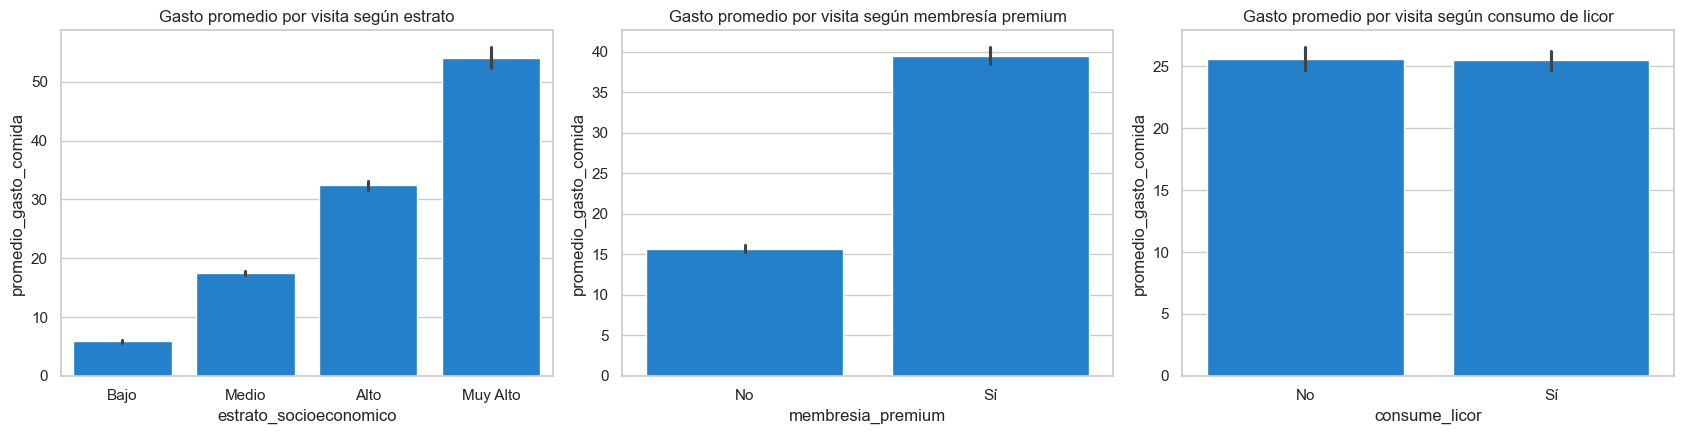

In [45]:
fig, ejes = plt.subplots(1, 3, figsize=(17, 4.5))

sns.barplot(data=df_int, x='estrato_socioeconomico', y='promedio_gasto_comida', order=ORDEN_ESTRATO, ax=ejes[0], color='#0984e3')
sns.barplot(data=df_int, x='membresia_premium', y='promedio_gasto_comida', order=['No', 'Sí'], ax=ejes[1], color='#0984e3')
sns.barplot(data=df_int, x='consume_licor', y='promedio_gasto_comida', order=['No', 'Sí'], ax=ejes[2], color='#0984e3')

ejes[0].set_title('Gasto promedio por visita según estrato')
ejes[1].set_title('Gasto promedio por visita según membresía premium')
ejes[2].set_title('Gasto promedio por visita según consumo de licor')

plt.tight_layout()
plt.show()

**Interpretación de P1:**
- **Solo dos variables se asocian a diferencias reales de gasto: el estrato y la membresía premium.** Las pruebas dan p-valores menores a 0,0001.
- Género, consumo de licor, ocio, medio de pago, preferencia alimenticia y **grupo de edad** no muestran diferencias significativas (p-valores entre 0,30 y 0,86). Diseñar campañas de precio o de monto según estas variables no tendría respaldo en los datos.
- **Pero cuidado con la membresía:** ya vimos que la membresía premium depende casi por completo del estrato. Las siguientes tablas verifican si la membresía influye **por sí sola** o si solo refleja el estrato.

In [46]:
# ¿La membresía premium influye por sí sola, o solo refleja el estrato?
# Comparamos el gasto mediano de premium vs. no premium DENTRO de cada estrato.
df_int.groupby(['estrato_socioeconomico', 'membresia_premium'])['promedio_gasto_comida'].agg(['median', 'count']).round(2).unstack().reindex(ORDEN_ESTRATO)

median        count      
membresia_premium          No     Sí    No    Sí
estrato_socioeconomico                          
Bajo                     6.85   8.37  1140     8
Medio                   17.61  18.08  1563   235
Alto                    32.28  32.89   422  1089
Muy Alto                46.25  53.52    44   883

In [47]:
for estrato in ORDEN_ESTRATO:
    dentro_del_estrato = df_int[df_int['estrato_socioeconomico'] == estrato]
    premium = dentro_del_estrato.loc[dentro_del_estrato['membresia_premium'] == 'Sí', 'promedio_gasto_comida']
    no_premium = dentro_del_estrato.loc[dentro_del_estrato['membresia_premium'] == 'No', 'promedio_gasto_comida']

    if min(len(premium), len(no_premium)) < 30:
        print(f'Estrato {estrato}: solo {min(len(premium), len(no_premium))} clientes en uno de los grupos -> no alcanza para comparar')
    else:
        print(f'Estrato {estrato}: premium vs. no premium -> p-valor = {stats.kruskal(premium, no_premium).pvalue:.2f}')

Estrato Bajo: solo 8 clientes en uno de los grupos -> no alcanza para comparar
Estrato Medio: premium vs. no premium -> p-valor = 0.68
Estrato Alto: premium vs. no premium -> p-valor = 0.83
Estrato Muy Alto: premium vs. no premium -> p-valor = 0.23


**Interpretación:** al comparar clientes **del mismo estrato**, la membresía premium **no cambia el gasto de forma significativa**: en el estrato Medio la mediana es $18,08 (premium) vs. $17,61 (p = 0,68), en el Alto $32,89 vs. $32,28 (p = 0,83) y en el Muy Alto $53,52 vs. $46,25 (p = 0,23, con apenas 44 clientes no premium). En el estrato Bajo hay solo 8 clientes premium, así que no se puede comparar. La diferencia que se veía antes se debía a que los clientes premium son casi todos de estratos altos. **La membresía parece ser un indicador del nivel socioeconómico y no la causa del mayor gasto.** Por eso no hay evidencia para asumir que promover la membresía aumentará el gasto (habría que probarlo con un experimento).

### P2 · ¿La preferencia alimenticia se relaciona con el estrato socioeconómico?

Una hipótesis muy natural: "la gente de estratos altos prefiere otra comida". Lo comprobamos con:
- una **tabla** con el porcentaje de cada preferencia dentro de cada estrato;
- la prueba de **chi-cuadrado** (p-valor menor a 0,05 = hay relación);
- la **V de Cramér**, un número que mide **qué tan fuerte** es la relación entre dos variables categóricas, de 0 (ninguna) a 1 (perfecta). Regla práctica: menos de 0,1 es despreciable; de 0,1 a 0,3, débil; de 0,3 a 0,5, moderada; más de 0,5, fuerte.

La V de Cramér no viene lista en las librerías, así que armamos una función chica que la calcula a partir del chi-cuadrado:

In [48]:
def cramer_v(a, b):
    tabla = pd.crosstab(a, b)                                          # tabla de conteos cruzados
    chi2, p_valor, grados, esperados = stats.chi2_contingency(tabla)   # prueba de chi-cuadrado
    n = tabla.values.sum()                                             # total de personas
    return (chi2 / (n * (min(tabla.shape) - 1))) ** 0.5                # fórmula de la V de Cramér

preferencias_alimenticias,Carnes,Mariscos,Otro,Pescado,Sin dato,Vegano,Vegetariano
estrato_socioeconomico,,,,,,,
Bajo,31.3,13.0,10.5,10.4,4.2,10.3,20.4
Medio,29.9,12.5,10.9,9.8,5.6,10.4,21.0
Alto,29.4,12.6,11.7,10.4,4.8,10.7,20.4
Muy Alto,26.9,14.2,10.5,10.1,5.1,11.3,21.9


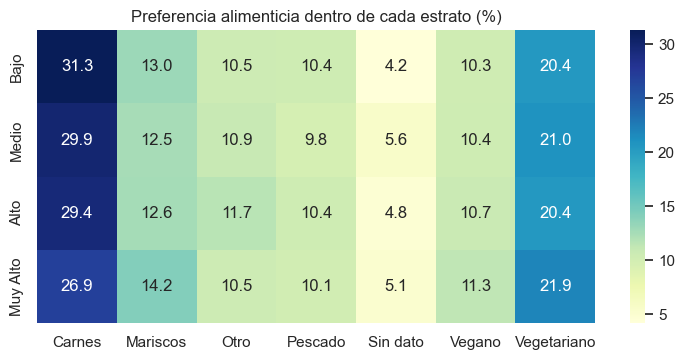

In [49]:
pref_por_estrato = pd.crosstab(df_int['estrato_socioeconomico'], df_int['preferencias_alimenticias'], normalize='index').mul(100).round(1).reindex(ORDEN_ESTRATO)
display(pref_por_estrato)

plt.figure(figsize=(9, 3.8))
sns.heatmap(pref_por_estrato, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Preferencia alimenticia dentro de cada estrato (%)')
plt.ylabel('')
plt.xlabel('')
plt.show()

In [50]:
tabla_pref_estrato = pd.crosstab(df_int['estrato_socioeconomico'], df_int['preferencias_alimenticias'])
chi2, p_valor, grados, esperados = stats.chi2_contingency(tabla_pref_estrato)

print(f"Preferencia alimenticia vs. estrato: p-valor = {p_valor:.2f} | V de Cramér = {cramer_v(df_int['estrato_socioeconomico'], df_int['preferencias_alimenticias']):.3f}")
print(f"Grupo de preferencia vs. estrato:    p-valor = {stats.chi2_contingency(pd.crosstab(df_int['estrato_socioeconomico'], df_int['grupo_preferencia']))[1]:.2f} | V de Cramér = {cramer_v(df_int['estrato_socioeconomico'], df_int['grupo_preferencia']):.3f}")

Preferencia alimenticia vs. estrato: p-valor = 0.90 | V de Cramér = 0.026
Grupo de preferencia vs. estrato:    p-valor = 0.62 | V de Cramér = 0.025


**Interpretación de P2:**
- **La respuesta es no: la preferencia alimenticia y el estrato son prácticamente independientes.** El chi-cuadrado da p = 0,90 y la V de Cramér es **0,026**, muy por debajo de 0,1 (relación despreciable). Agrupando las preferencias en 4 grupos el resultado es igual (p = 0,62; V = 0,025).
- En todos los estratos el reparto es casi el mismo: Carnes entre 27% y 31%, Vegetariano entre 20% y 22%, Mariscos y Pescado juntos entre 22% y 24%. Las pequeñas diferencias (por ejemplo, menos Carnes en el estrato Muy Alto: 26,9% frente a 31,3% en el Bajo) están dentro de lo que se espera por azar.
- **Qué implica:** el estrato no permite adivinar qué come una persona. La demanda vegetariana/vegana existe en todos los niveles (entre 30,7% y 33,2%), y para conocer la preferencia de cada cliente hay que preguntársela. **El contenido de una campaña (qué comida) y su presupuesto (cuánto gasta el cliente) son dos decisiones independientes.**

### P3 · ¿Qué otras variables están relacionadas entre sí? *(mapa de asociaciones)*

En vez de probar las variables de a una, calculamos la V de Cramér para **todas las combinaciones** de variables categóricas y lo mostramos en un solo mapa de calor. Las celdas oscuras son relaciones fuertes; las claras, ausencia de relación. Es una forma rápida de descubrir qué vale la pena mirar.

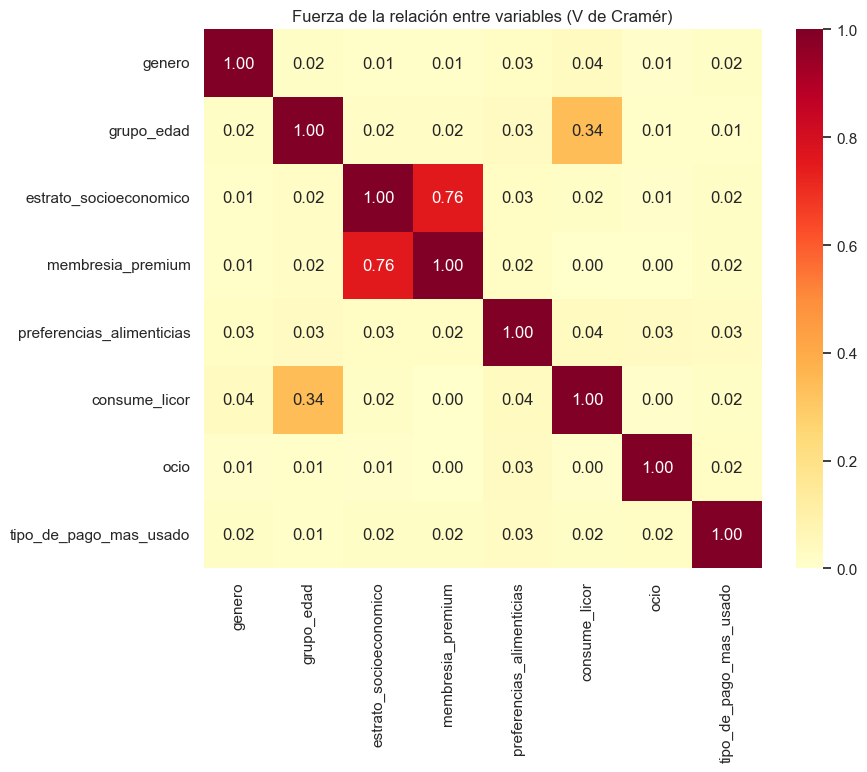

In [51]:
variables_cat = ['genero', 'grupo_edad', 'estrato_socioeconomico', 'membresia_premium', 'preferencias_alimenticias',
                 'consume_licor', 'ocio', 'tipo_de_pago_mas_usado']

matriz_v = pd.DataFrame(index=variables_cat, columns=variables_cat, dtype=float)
for a in variables_cat:
    for b in variables_cat:
        matriz_v.loc[a, b] = cramer_v(df_int[a], df_int[b])

plt.figure(figsize=(9, 7))
sns.heatmap(matriz_v, annot=True, fmt='.2f', cmap='YlOrRd', vmin=0, vmax=1)
plt.title('Fuerza de la relación entre variables (V de Cramér)')
plt.show()

In [52]:
# Las 5 relaciones más fuertes (nos quedamos con la mitad de arriba de la matriz para no repetir pares)
mitad_superior = matriz_v.where(np.triu(np.ones(matriz_v.shape, dtype=bool), k=1))
mitad_superior.stack().sort_values(ascending=False).head(5).round(2)

estrato_socioeconomico     membresia_premium            0.76
grupo_edad                 consume_licor                0.34
genero                     consume_licor                0.04
preferencias_alimenticias  consume_licor                0.04
grupo_edad                 preferencias_alimenticias    0.03
dtype: float64

**Interpretación de P3:**
- De 28 pares de variables, **solo dos muestran una relación clara**:
  1. **Estrato y membresía premium** (V = 0,76, fuerte): ya lo habíamos visto; la membresía es un reflejo del estrato.
  2. **Edad y consumo de licor** (V = 0,34, moderada): es un hallazgo nuevo y lo analizamos en P4.
- Todo lo demás está por debajo de 0,05: **el género, la preferencia alimenticia, el medio de pago y el ocio no se relacionan con ninguna otra variable**. Son ruido a la hora de segmentar.
- Como se probaron muchos pares, alguno podría salir "significativo" por casualidad; pero estas dos relaciones están muy lejos del ruido (p-valores prácticamente nulos).

### P4 · ¿Quién consume licor?

El mapa de asociaciones mostró una relación inesperada entre **la edad y el consumo de licor**. La miramos de cerca: primero por grupo de edad y después edad por edad.

In [53]:
licor_por_edad = pd.crosstab(df_int['grupo_edad'], df_int['consume_licor'], normalize='index').mul(100).round(1)
licor_por_edad['clientes'] = df_int['grupo_edad'].value_counts()
licor_por_edad

consume_licor,No,Sí,clientes
grupo_edad,,,
18-30,9.6,90.4,1135
31-50,48.5,51.5,1746
51-70,34.3,65.7,1675
71+,58.0,42.0,828


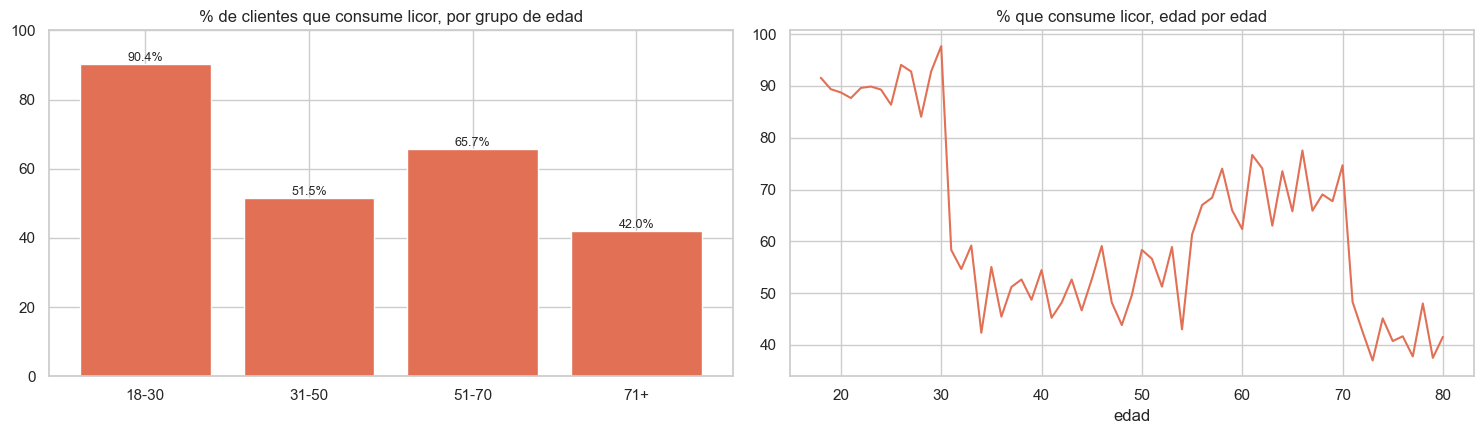

In [54]:
fig, ejes = plt.subplots(1, 2, figsize=(15, 4.5))

barras = ejes[0].bar(licor_por_edad.index.astype(str), licor_por_edad['Sí'], color='#e17055')
ejes[0].bar_label(barras, fmt='%.1f%%', fontsize=9)
ejes[0].set_title('% de clientes que consume licor, por grupo de edad')
ejes[0].set_ylim(0, 100)

# edad por edad: (consume_licor == 'Sí') vale True/False; el promedio de True/False es la proporción
licor_edad_por_edad = (df_int['consume_licor'] == 'Sí').groupby(df_int['edad']).mean() * 100
ejes[1].plot(licor_edad_por_edad.index, licor_edad_por_edad.values, color='#e17055')
ejes[1].set_title('% que consume licor, edad por edad')
ejes[1].set_xlabel('edad')

plt.tight_layout()
plt.show()

In [55]:
# Los escalones del gráfico: el % que consume licor justo antes y después de los 30 y de los 70 años
licor_edad_por_edad.loc[[29, 30, 31, 32, 69, 70, 71, 72]].round(1)

edad
29    92.8
30    97.7
31    58.3
32    54.7
69    67.7
70    74.7
71    48.3
72    42.5
Name: consume_licor, dtype: float64

In [56]:
# ¿Y el estrato? Comparamos con lo que pasaba con el estrato: el consumo de licor casi no cambia
print(pd.crosstab(df_int['estrato_socioeconomico'], df_int['consume_licor'], normalize='index').mul(100).round(1).reindex(ORDEN_ESTRATO))

p_licor_estrato = stats.chi2_contingency(pd.crosstab(df_int['estrato_socioeconomico'], df_int['consume_licor']))[1]
print(f'\nLicor vs. estrato: p-valor = {p_licor_estrato:.2f}')

consume_licor             No    Sí
estrato_socioeconomico            
Bajo                    38.3  61.7
Medio                   36.6  63.4
Alto                    36.8  63.2
Muy Alto                38.3  61.7

Licor vs. estrato: p-valor = 0.69


In [57]:
# ¿La edad se relaciona con el gasto, la frecuencia o los ingresos?
for variable in ['promedio_gasto_comida', 'frecuencia_visita', 'ingresos_mensuales']:
    datos_por_edad = [datos for nombre, datos in df_int.groupby('grupo_edad', observed=True)[variable]]
    print(f'{variable} según grupo de edad: p-valor = {stats.kruskal(*datos_por_edad).pvalue:.2f}')

promedio_gasto_comida según grupo de edad: p-valor = 0.86
frecuencia_visita según grupo de edad: p-valor = 0.96
ingresos_mensuales según grupo de edad: p-valor = 0.50


**Interpretación de P4:**
- **El consumo de licor depende de la edad, no del estrato.** Entre los 18 y 30 años consume el **90,4%** (1.135 clientes, el 21% de la base). Después baja al 51,5% (31-50), sube al 65,7% (51-70) y cae al 42,0% pasados los 70.
- En el gráfico edad por edad se ve un **escalón muy marcado**: el consumo pasa de 98% a los 30 años a 58% a los 31 (y de 75% a los 70 años a 48% a los 71). Con el estrato no pasa nada: entre 61,7% y 63,4% en los cuatro niveles (p = 0,69).
- **La edad no se relaciona con nada más:** ni el gasto (p = 0,86), ni la frecuencia (p = 0,96), ni los ingresos (p = 0,50). Es decir, la edad sirve para una sola cosa: saber a quién ofrecerle licor.
- **Qué implica:** las campañas de bares, coctelería y licor conviene dirigirlas a los **jóvenes de 18 a 30 años**, y no segmentarlas por nivel socioeconómico. Y en Chicago hay oferta para eso: el 43% de los restaurantes de Yelp tiene alguna categoría de bar.
- *Nota:* un cambio tan brusco entre los 30 y los 31 años es raro en datos reales (que suelen variar de forma gradual), lo que sugiere que estos datos fueron generados por reglas. El patrón es útil igual, pero conviene validarlo con datos reales.

### P5 · ¿La oferta de Chicago cubre lo que los clientes **prefieren comer**?

Comparamos, por grupo de preferencia, **cuántos clientes** lo prefieren contra **cuántos restaurantes de Yelp** lo ofrecen.

In [58]:
nombres_grupos = ['Carnes', 'Mariscos y pescado', 'Vegetariano/Vegano', 'Otro']
columna_yelp = {'Carnes': 'carnes', 'Mariscos y pescado': 'mariscos_pescado',
                'Vegetariano/Vegano': 'vegetariano_vegano', 'Otro': 'otro'}

filas = []
for grupo in nombres_grupos:
    clientes_del_grupo = df_int[df_int['grupo_preferencia'] == grupo]
    restaurantes_del_grupo = df_yelp[df_yelp[columna_yelp[grupo]]]
    filas.append({'grupo_preferencia': grupo,
                  'n_clientes': len(clientes_del_grupo),
                  'gasto_prom': clientes_del_grupo['promedio_gasto_comida'].mean(),
                  'n_restaurantes': len(restaurantes_del_grupo),
                  'rating_prom': restaurantes_del_grupo['rating'].mean()})

oferta = pd.DataFrame(filas)
oferta['pct_clientes'] = oferta['n_clientes'] / len(df_int) * 100            # sobre todos los clientes
oferta['pct_restaurantes'] = oferta['n_restaurantes'] / len(df_yelp) * 100   # sobre todos los restaurantes
oferta['clientes_por_restaurante'] = oferta['n_clientes'] / oferta['n_restaurantes']
oferta['indice_cobertura'] = oferta['pct_restaurantes'] / oferta['pct_clientes']   # menor a 1 = oferta insuficiente
oferta.round(2)

,grupo_preferencia,n_clientes,gasto_prom,n_restaurantes,rating_prom,pct_clientes,pct_restaurantes,clientes_por_restaurante,indice_cobertura
0,Carnes,1589,24.94,32,4.31,29.51,13.33,49.66,0.45
1,Mariscos y pescado,1242,25.90,21,4.41,23.07,8.75,59.14,0.38
2,Vegetariano/Vegano,1694,25.82,2,4.10,31.46,0.83,847.00,0.03
3,Otro,591,24.71,191,4.40,10.98,79.58,3.09,7.25


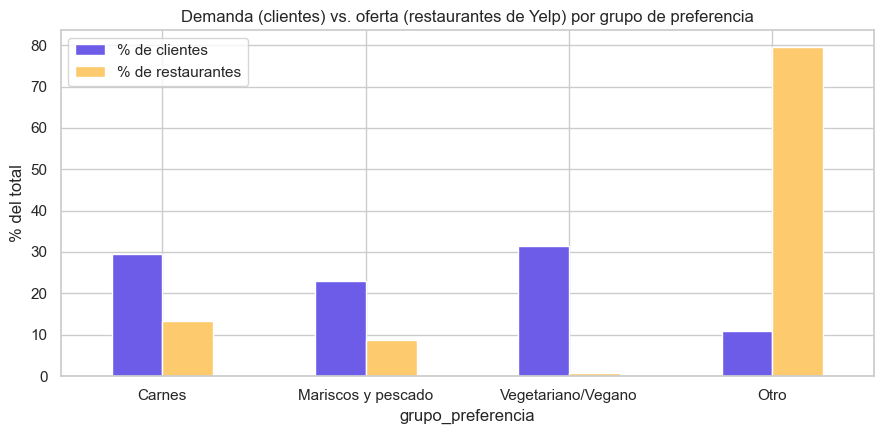

In [59]:
comparacion = oferta.set_index('grupo_preferencia')[['pct_clientes', 'pct_restaurantes']]
comparacion.plot(kind='bar', figsize=(9, 4.5), color=['#6c5ce7', '#fdcb6e'])
plt.title('Demanda (clientes) vs. oferta (restaurantes de Yelp) por grupo de preferencia')
plt.ylabel('% del total')
plt.xticks(rotation=0)
plt.legend(['% de clientes', '% de restaurantes'])
plt.tight_layout()
plt.show()

**Interpretación de P5 (demanda vs. oferta por tipo de comida):**
- **Vegetariano/Vegano es el mayor desajuste.** Representa el **31,5% de los clientes** (el grupo más grande), pero solo **2 de los 240 restaurantes** de Yelp (0,8%) son de cocina vegetariana o vegana: hay **847 clientes por restaurante**, contra 50 en Carnes y 59 en Mariscos y pescado. El índice de cobertura es 0,03 (una oferta 30 veces menor que la demanda).
- Además, esos dos restaurantes tienen un rating promedio de **4,10**, el más bajo de todos los grupos (4,31 en Carnes, 4,41 en Mariscos y pescado): no solo hay poca oferta, tampoco es la mejor valorada.
- **Carnes y Mariscos/pescado también están subatendidos** (índices de 0,45 y 0,38), aunque de forma mucho menos marcada.
- La oferta se concentra en la categoría **Otro** (191 restaurantes, 80% del total). En ella pesan mucho los bares: el **43% de los restaurantes tiene alguna categoría de bar**.
- Los 268 clientes `Sin dato` no tienen un grupo para cruzar con Yelp, así que no aparecen en la tabla.

### P6 · ¿La oferta de Chicago cubre lo que los clientes **pueden pagar**?

Además de *qué* quieren comer, importa *cuánto* pueden gastar. Yelp clasifica los restaurantes con signos de pesos. Como referencia, los rangos aproximados que usa Yelp son: `$` hasta 10 USD, `$$` de 11 a 30, `$$$` de 31 a 60 y `$$$$` más de 60. Con eso ubicamos a cada cliente en el rango que corresponde a su gasto por visita y lo comparamos con la oferta.

In [60]:
# Solo los clientes que gastan algo (los que tienen gasto 0 no visitan)
con_gasto = df_int[df_int['promedio_gasto_comida'] > 0].copy()
con_gasto['rango_precio'] = pd.cut(con_gasto['promedio_gasto_comida'], bins=[0, 10, 30, 60, 1000], labels=['$', '$$', '$$$', '$$$$'])

pct_clientes = con_gasto['rango_precio'].value_counts(normalize=True) * 100

# Solo los restaurantes que informan su precio (a 96 les falta)
restaurantes_con_precio = df_yelp[df_yelp['precio'].notna()]
pct_restaurantes = restaurantes_con_precio['precio'].value_counts(normalize=True) * 100

tabla_precio = pd.DataFrame({'% de clientes': pct_clientes, '% de restaurantes': pct_restaurantes}).reindex(['$', '$$', '$$$', '$$$$']).round(1)
tabla_precio

,% de clientes,% de restaurantes
$,28.1,0.7
$$,42.1,64.6
$$$,22.0,26.4
$$$$,7.8,8.3


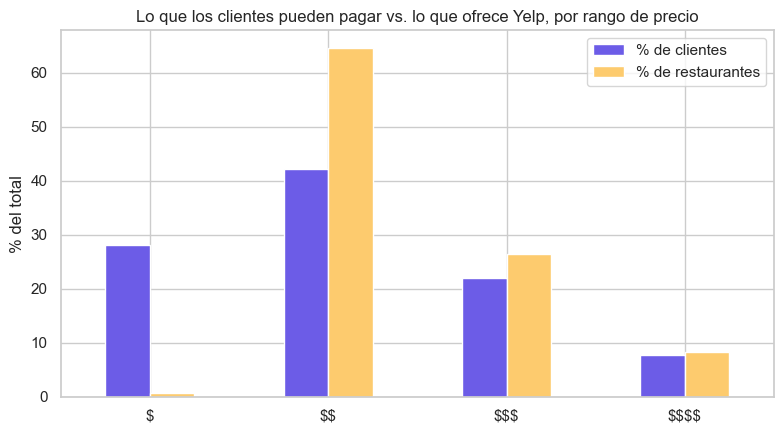

In [61]:
tabla_precio.plot(kind='bar', figsize=(8, 4.5), color=['#6c5ce7', '#fdcb6e'])
plt.title('Lo que los clientes pueden pagar vs. lo que ofrece Yelp, por rango de precio')
plt.ylabel('% del total')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [62]:
# ¿Qué rango de precio le corresponde a cada estrato? (% dentro de cada estrato)
pd.crosstab(con_gasto['estrato_socioeconomico'], con_gasto['rango_precio'], normalize='index').mul(100).round(1).reindex(ORDEN_ESTRATO)

rango_precio,$,$$,$$$,$$$$
estrato_socioeconomico,,,,
Bajo,99.3,0.7,0.0,0.0
Medio,20.6,79.4,0.0,0.0
Alto,9.8,35.1,55.1,0.0
Muy Alto,4.4,20.6,31.6,43.4


In [63]:
# Las "joyas ocultas" de Yelp (rating de 4.6 o más y pocas reseñas, ver Avance_API_Yelp): ¿en qué rango de precio están?
con_resenas_suficientes = df_yelp[df_yelp['review_count'] >= 30]   # al menos 30 reseñas para que la nota sea confiable
joyas = con_resenas_suficientes[(con_resenas_suficientes['rating'] >= 4.6) & (con_resenas_suficientes['review_count'] < df_yelp['review_count'].median())]
print(f'Joyas ocultas: {len(joyas)}')
joyas['precio'].fillna('Sin dato').value_counts()

Joyas ocultas: 24


precio
Sin dato    19
$$           4
$$$$         1
Name: count, dtype: int64

**Interpretación de P6 (demanda vs. oferta por precio):**
- **Hay una brecha en el extremo económico.** El **28%** de los clientes que visitan gasta hasta $10 por visita (rango `$`), pero solo **1 de los 144** restaurantes que informan precio (0,7%) es `$`. En cambio, `$$` concentra el 65% de los restaurantes frente al 42% de los clientes.
- **El estrato define el rango de precio:** el 99% de los clientes del estrato Bajo que visitan gasta en el rango `$`; en el Medio, el 79% está en `$$`; en el Alto, el 55% en `$$$`; y en el Muy Alto el 43% llega a `$$$$`.
- **Qué implica:** para los clientes de Bajo valor la limitación probable no es que no quieran salir, sino que casi no hay dónde. Las promociones para ellos deberían apoyarse en descuentos, combos o delivery en restaurantes `$$`, o en sumar restaurantes económicos como aliados.
- **Joyas ocultas:** son 24 restaurantes con rating de 4,6 o más, al menos 30 reseñas y menos reseñas que la mediana. **19 de los 24 no informan precio**, así que no sabemos si son accesibles; conviene consultarlo antes de promocionarlos.
- **Cautela:** los rangos de dólares de Yelp son aproximados, al 40% de los restaurantes les falta el precio, y la muestra de Yelp favorece a locales populares, que rara vez son los más baratos. La brecha puede estar exagerada, pero la dirección es clara.

### P7 · ¿Cómo segmentamos a los clientes según su valor y cómo es cada segmento?

Creamos un **índice de valor** = `promedio_gasto_comida × frecuencia_visita` (cuánto gasta por visita multiplicado por cuánto visita). Es un índice relativo para ordenar clientes, no un monto en dólares.

Reglas del segmento:
- **Inactivo:** `frecuencia_visita == 0` (no visita).
- **Alto valor:** el 25% de clientes activos con mayor índice.
- **Bajo valor:** el 25% de clientes activos con menor índice.
- **Valor medio:** el 50% restante.

In [64]:
df_int['indice_valor'] = df_int['promedio_gasto_comida'] * df_int['frecuencia_visita']

# Los umbrales se calculan solo entre los clientes activos (los que visitan)
activos = df_int[df_int['frecuencia_visita'] > 0]
q25 = activos['indice_valor'].quantile(0.25)
q75 = activos['indice_valor'].quantile(0.75)
print(f'Umbrales del índice de valor entre clientes activos: Q25 = {q25:.1f} | Q75 = {q75:.1f}')

Umbrales del índice de valor entre clientes activos: Q25 = 31.8 | Q75 = 187.6


In [65]:
# Asignamos el segmento con máscaras: primero "Valor medio" para todos y después corregimos
df_int['segmento'] = 'Valor medio'
df_int.loc[df_int['indice_valor'] >= q75, 'segmento'] = 'Alto valor'
df_int.loc[df_int['indice_valor'] <= q25, 'segmento'] = 'Bajo valor'
df_int.loc[df_int['frecuencia_visita'] == 0, 'segmento'] = 'Inactivo'

ORDEN_SEG = ['Alto valor', 'Valor medio', 'Bajo valor', 'Inactivo']
pd.DataFrame({
    'conteo': df_int['segmento'].value_counts(),
    'porcentaje': (df_int['segmento'].value_counts(normalize=True) * 100).round(2),
}).reindex(ORDEN_SEG)

,conteo,porcentaje
segmento,,
Alto valor,1281,23.79
Valor medio,2561,47.57
Bajo valor,1281,23.79
Inactivo,261,4.85


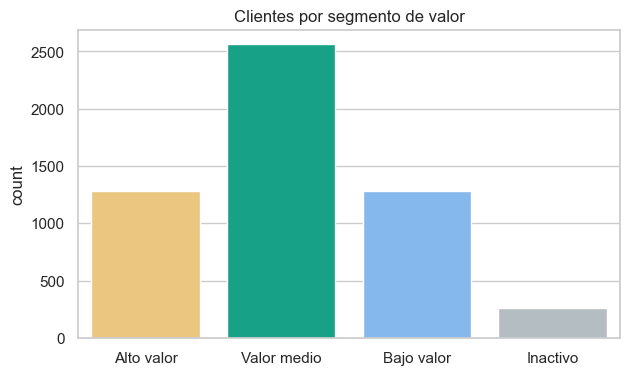

In [66]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df_int, x='segmento', order=ORDEN_SEG, hue='segmento', legend=False,
              palette=['#00b894', '#74b9ff', '#fdcb6e', '#b2bec3'])
plt.title('Clientes por segmento de valor')
plt.xlabel('')
plt.show()

In [67]:
# Perfil numérico de cada segmento
perfil = df_int.groupby('segmento').agg(
    clientes=('id_persona', 'count'),
    gasto_medio=('promedio_gasto_comida', 'mean'),
    frecuencia_media=('frecuencia_visita', 'mean'),
    ingreso_medio=('ingresos_mensuales', 'mean'),
    edad_media=('edad', 'mean'),
)

# Porcentajes de "Sí" (premium y licor) por segmento
perfil['pct_premium'] = (df_int['membresia_premium'] == 'Sí').groupby(df_int['segmento']).mean() * 100
perfil['pct_licor'] = (df_int['consume_licor'] == 'Sí').groupby(df_int['segmento']).mean() * 100

# La categoría más frecuente en cada segmento
perfil['estrato_mas_comun'] = pd.crosstab(df_int['segmento'], df_int['estrato_socioeconomico']).idxmax(axis=1)
perfil['preferencia_mas_comun'] = pd.crosstab(df_int['segmento'], df_int['preferencias_alimenticias']).idxmax(axis=1)

perfil.reindex(ORDEN_SEG).round(1)

,clientes,gasto_medio,frecuencia_media,ingreso_medio,edad_media,pct_premium,pct_licor,estrato_mas_comun,preferencia_mas_comun
segmento,,,,,,,,,
Alto valor,1281,57.8,6.5,10246.9,48.8,85.0,61.3,Muy Alto,Carnes
Valor medio,2561,20.8,4.4,4760.1,48.7,39.9,63.8,Medio,Carnes
Bajo valor,1281,7.8,2.4,1857.6,48.4,7.9,63.2,Bajo,Carnes
Inactivo,261,0.0,0.0,1197.8,50.1,0.8,55.9,Bajo,Carnes


grupo_preferencia,Carnes,Mariscos y pescado,Otro,Sin dato,Vegetariano/Vegano
segmento,,,,,
Alto valor,27.6,24.0,10.4,5.1,32.9
Valor medio,29.6,22.8,11.3,5.3,31.0
Bajo valor,31.1,23.4,10.5,4.3,30.7
Inactivo,30.3,19.5,13.0,4.2,33.0


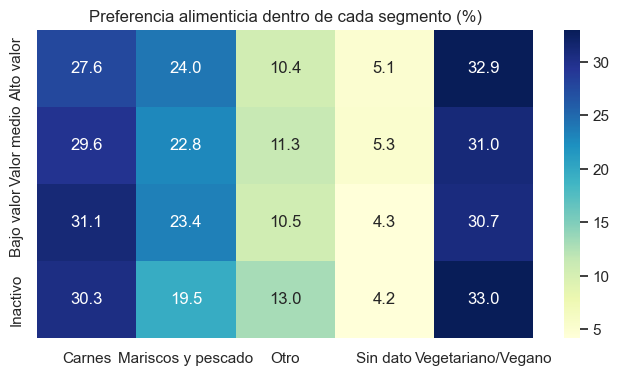

In [68]:
# Composición de cada segmento por grupo de preferencia (% dentro del segmento)
composicion = pd.crosstab(df_int['segmento'], df_int['grupo_preferencia'], normalize='index').mul(100).round(1).reindex(ORDEN_SEG)
display(composicion)

plt.figure(figsize=(8, 4))
sns.heatmap(composicion, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Preferencia alimenticia dentro de cada segmento (%)')
plt.ylabel('')
plt.xlabel('')
plt.show()

In [69]:
# ¿Cuánto del valor total concentra cada segmento?
valor_por_segmento = df_int.groupby('segmento')['indice_valor'].sum()

pd.DataFrame({
    '% de clientes': (df_int['segmento'].value_counts(normalize=True) * 100).round(1),
    '% del valor total': (valor_por_segmento / valor_por_segmento.sum() * 100).round(1),
}).reindex(ORDEN_SEG)

,% de clientes,% del valor total
segmento,,
Alto valor,23.8,66.0
Valor medio,47.6,30.8
Bajo valor,23.8,3.2
Inactivo,4.8,0.0


**Interpretación de P7 (segmentos de valor):**
- **Tamaño y concentración del valor:** *Alto valor* (1.281 clientes, 23,8%), *Valor medio* (2.561, 47,6%), *Bajo valor* (1.281, 23,8%) e *Inactivo* (261, 4,8%). El segmento **Alto valor (24% de los clientes) genera el 66% del valor total**; los de Bajo valor aportan solo el 3,2%.
- **El valor lo define el nivel socioeconómico.** Alto valor está formado únicamente por estratos Muy Alto (55%) y Alto (45%), con ingreso medio de **$10.247** y **85% de membresía premium**. Bajo valor son sobre todo estrato Bajo (67%) y Medio (28%), con ingreso medio de $1.858. Los **261 inactivos son todos de estrato Bajo** (ingreso mediano de $1.184).
- **La preferencia alimenticia es independiente del valor** (lo que ya mostró P2): en todos los segmentos, entre 31% y 33% de los clientes es vegetariano/vegano. Por eso una campaña de contenido (qué ofrecer) y una de inversión (cuánto gastar en el cliente) deben pensarse por separado.
- **Oportunidad concreta:** hay **421 clientes de Alto valor que prefieren cocina vegetariana/vegana**, sobre una oferta de solo 2 restaurantes en Yelp.

### P8 · ¿Dónde está el potencial de crecimiento?

El índice de valor mezcla dos cosas: **cuánto gasta** el cliente en cada visita y **cuántas veces visita**. Separándolas aparecen cuatro tipos de cliente activo (partiendo cada variable en la mediana):

| | Visita poco | Visita mucho |
|---|---|---|
| **Gasta mucho** | *Ocasionales de alto gasto* | *Embajadores* |
| **Gasta poco** | *Distantes* | *Frecuentes de bajo gasto* |

La pregunta clave: ¿cuánto crecería el negocio si los **ocasionales de alto gasto** visitaran con la frecuencia de los embajadores?

In [70]:
activos = df_int[df_int['frecuencia_visita'] > 0]
mediana_frecuencia = activos['frecuencia_visita'].median()
mediana_gasto = activos['promedio_gasto_comida'].median()
print(f'Medianas entre clientes activos: frecuencia = {mediana_frecuencia:.0f} | gasto = ${mediana_gasto:.2f}')

visita_mucho = activos['frecuencia_visita'] > mediana_frecuencia
gasta_mucho = activos['promedio_gasto_comida'] > mediana_gasto

embajadores = activos[visita_mucho & gasta_mucho]
ocasionales = activos[~visita_mucho & gasta_mucho]
frecuentes_economicos = activos[visita_mucho & ~gasta_mucho]
distantes = activos[~visita_mucho & ~gasta_mucho]

Medianas entre clientes activos: frecuencia = 4 | gasto = $20.09


In [71]:
tipos = {'Embajadores': embajadores, 'Ocasionales de alto gasto': ocasionales,
         'Frecuentes de bajo gasto': frecuentes_economicos, 'Distantes': distantes}

filas = []
for nombre, datos in tipos.items():
    filas.append({'tipo de cliente': nombre,
                  'clientes': len(datos),
                  'frecuencia_media': datos['frecuencia_visita'].mean(),
                  'gasto_medio': datos['promedio_gasto_comida'].mean(),
                  '% del valor total': datos['indice_valor'].sum() / df_int['indice_valor'].sum() * 100})
pd.DataFrame(filas).round(1)

,tipo de cliente,clientes,frecuencia_media,gasto_medio,% del valor total
0,Embajadores,1603,6.4,48.5,70.2
1,Ocasionales de alto gasto,957,3.6,33.0,15.6
2,Frecuentes de bajo gasto,676,5.7,12.7,6.6
3,Distantes,1887,2.7,10.3,7.5


In [72]:
# ¿Qué estrato tienen los ocasionales de alto gasto?
(ocasionales['estrato_socioeconomico'].value_counts(normalize=True) * 100).round(1)

estrato_socioeconomico
Medio       54.1
Alto        41.5
Muy Alto     4.4
Name: proportion, dtype: float64

In [73]:
# Escenario: ¿cuánto sumaría si los ocasionales de alto gasto visitaran más?
valor_total = df_int['indice_valor'].sum()

extra_una_visita = ocasionales['promedio_gasto_comida'].sum()   # cada uno visita 1 vez más
frecuencia_embajadores = embajadores['frecuencia_visita'].mean()
extra_como_embajadores = ((frecuencia_embajadores - ocasionales['frecuencia_visita']) * ocasionales['promedio_gasto_comida']).sum()

print(f'Una visita más por cliente ocasional:            +{extra_una_visita / valor_total:.1%} del valor total')
print(f'Visitando como los embajadores ({frecuencia_embajadores:.1f} visitas):    +{extra_como_embajadores / valor_total:.1%} del valor total')

Una visita más por cliente ocasional:            +4.3% del valor total
Visitando como los embajadores (6.4 visitas):    +11.6% del valor total


**Interpretación de P8 (potencial de crecimiento):**
- Los **embajadores** (1.603 clientes) visitan 6,4 veces y gastan $48,5 por visita: concentran el **70% del valor**.
- Los **ocasionales de alto gasto** (957 clientes) gastan $33,0 por visita, bastante más que la mediana, pero visitan solo 3,6 veces. Son sobre todo de estrato Medio (54%) y Alto (42%). **Tienen el presupuesto; les falta la frecuencia.**
- Los **frecuentes de bajo gasto** (676) visitan 5,7 veces pero gastan $12,7: su margen de mejora está en el ticket (combos, upselling), pero pesan solo el 6,6% del valor.
- **Escenario:** si cada cliente ocasional de alto gasto visitara **una vez más**, el valor total subiría un **4,3%**; si visitara **con la frecuencia de los embajadores** (6,4 visitas), subiría un **11,6%**. Es más que todo el valor que hoy aportan los frecuentes de bajo gasto (6,6%).
- *Aclaración:* es un escenario, no una predicción. Supone que el gasto por visita se mantiene y que se puede lograr que visiten más; habría que probarlo.

### Unir la información de Yelp a la base final
Unimos a cada cliente la información de Yelp de su grupo de preferencia (la misma integración del Avance #2). Queda la **base final** en memoria: clientes + Yelp + grupos de edad y preferencia + índice de valor + segmento. Los CSV de `data/` quedan como en el Avance #2.

In [74]:
yelp_por_grupo = oferta[['grupo_preferencia', 'n_restaurantes', 'rating_prom', 'clientes_por_restaurante', 'indice_cobertura']]
base_final = pd.merge(df_int, yelp_por_grupo, on='grupo_preferencia', how='left')

print(f'Clientes: {len(df_int):,} -> base final: {len(base_final):,} filas x {base_final.shape[1]} columnas')

Clientes: 5,384 -> base final: 5,384 filas x 21 columnas


## 9. Recomendaciones de segmentación

Resumen de lo que dicen los datos de los clientes de Chicago y qué hacer con eso. El documento completo, pensado para el equipo comercial, está en `Documentacion/Recomendaciones.pdf`.

### Hallazgos clave
1. **El valor lo define el estrato; el gusto, la preferencia alimenticia, y no se relacionan.** Preferencia y estrato son independientes (V de Cramér = 0,03), así que cada segmento de valor tiene la misma mezcla de preferencias.
2. **El 24% de los clientes genera el 66% del valor.** Son de estratos Alto y Muy Alto, con ingresos medios de $10.247.
3. **La membresía premium no aumenta el gasto por sí sola:** refleja el estrato. Dentro de un mismo estrato, premium y no premium gastan igual.
4. **Vegetarianos y veganos son el mayor grupo (31,5%) y casi no tienen oferta** en Yelp (2 restaurantes, 847 clientes por restaurante).
5. **Hay una brecha de precio:** el 28% de los clientes gasta hasta $10 por visita, pero solo el 0,7% de los restaurantes con precio es `$`.
6. **El licor depende de la edad, no del estrato:** lo consume el 90% de los clientes de 18 a 30 años y el 55% de los demás.
7. **Los ocasionales de alto gasto son la palanca de crecimiento:** 957 clientes con presupuesto que visitan poco; que lleguen a la frecuencia de los embajadores sumaría ~12% al valor.
8. **Hay "joyas ocultas" en Yelp:** 24 restaurantes muy bien calificados y poco conocidos, porque el rating baja a medida que suben las reseñas.
9. **Género, medio de pago y ocio no diferencian el comportamiento** (y la edad solo importa para el licor).

### Recomendaciones

| Prioridad | Segmento / tema | Acción propuesta | Evidencia | Cómo medirlo |
|---|---|---|---|---|
| 1 | **Alto valor** (1.281 clientes) | Programa de retención y experiencias exclusivas; comunicaciones personalizadas según su preferencia alimenticia. Es el segmento a proteger. | 24% de los clientes, 66% del valor total, 85% premium. | Retención y frecuencia de visita del segmento. |
| 2 | **Ocasionales de alto gasto** (957 clientes) | Beneficios por visita adicional (segundo canje, recordatorios, eventos) para acercar su frecuencia a la de los embajadores. | Gastan $33 por visita pero visitan 3,6 veces (embajadores: 6,4). Una visita más suma 4,3% al valor total; igualar a los embajadores, 11,6%. | Visitas por cliente, grupo de prueba vs. control. |
| 3 | **Vegetarianos/veganos de Alto valor** (421 clientes) | Campañas de descubrimiento con los pocos restaurantes vegetarianos que existen y captación de nuevos negocios aliados con esa oferta. | 31,5% de la demanda frente a 0,8% de la oferta; el rating de esa oferta (4,10) es el más bajo. | Reservas y cupones canjeados en aliados vegetarianos; nuevos aliados sumados. |
| 4 | **Jóvenes de 18 a 30 años** (1.135 clientes) | Alianzas con bares y coctelería, dirigidas por edad y no por estrato. | El 90,4% consume licor (contra ~55% del resto); el 43% de los restaurantes de Yelp tiene categoría de bar. | Canjes en bares por grupo de edad. |
| 5 | **Bajo valor** (1.281) e **Inactivos** (261) | Ofertas accesibles por delivery y combos en restaurantes `$$`, y sumar restaurantes económicos como aliados. Reactivación simple con incentivo de primera visita. | El 28% de los clientes gasta hasta $10 y solo el 0,7% de los restaurantes es `$`. Los inactivos son todos de estrato Bajo. | Costo por visita incremental; tasa de reactivación. |
| 6 | **Joyas ocultas de Yelp** (24 restaurantes) | Promocionarlas en las campañas de descubrimiento, previo relevamiento de sus precios (19 no lo informan). | Rating de 4,6 o más, 30 o más reseñas y por debajo de la mediana de visibilidad. | Reservas y clics por restaurante promocionado. |
| 7 | **Membresía premium** | No asumir que sube el gasto: probarlo con un test A/B en el segmento Valor medio (2.561). | Dentro de cada estrato, premium y no premium gastan lo mismo. | Aumento de gasto por cliente, grupo de prueba vs. control. |
| 8 | **Medios de pago** | Que las promociones se puedan canjear en el local y no solo con app. No priorizar criptomonedas. | El efectivo es el 39% de los pagos y la cripto solo 1,8%. | Canjes por medio de pago. |
| 9 | **Calidad del dato** | Capturar la preferencia alimenticia en el alta (5% sin dato: el estrato no permite deducirla), validar edad y frecuencia en el origen y controlar correos repetidos. | 29 edades inválidas, 286 frecuencias negativas y 14 correos repetidos. | % de registros con errores. |

> **Nota:** las recomendaciones 3 y 4 combinan un segmento con una preferencia o una edad, aprovechando que las variables son independientes entre sí. El mismo criterio puede aplicarse a los demás segmentos.

## 10. Limitaciones a tener en cuenta
- **Yelp es una muestra:** los 240 restaurantes son el **3%** de los 7.900 que Yelp registra para la búsqueda, ordenados por relevancia. Favorecen a los negocios populares (mediana de 234 reseñas) y probablemente subrepresentan a los baratos: solo 1 restaurante figura con precio `$` y el 40% no informa precio.
- **Los rangos de precio de Yelp son aproximados** (`$` hasta 10 USD, `$$` de 11 a 30, `$$$` de 31 a 60, `$$$$` más de 60), por lo que la brecha de precio es una estimación.
- **El cruce por tipo de comida es una aproximación.** Las categorías de Yelp describen el tipo de negocio, no el menú: una parrilla puede tener opciones vegetarianas. Por eso hicimos un análisis de sensibilidad (definición amplia: 9 restaurantes, 3,8%), que no cambia la conclusión.
- **Ciudad de residencia no es ciudad de consumo:** asumimos que los clientes comen en Chicago.
- **El índice de valor es relativo:** no conocemos la unidad de `frecuencia_visita`, así que ordena clientes pero no equivale a dólares. El escenario de crecimiento (+4,3% y +11,6%) es una simulación, no una predicción.
- **Los datos de clientes son sintéticos** (provistos por el curso): las relaciones tan limpias entre variables (por ejemplo, el salto del consumo de licor entre los 30 y los 31 años, o que la edad no se relacione con nada más) pueden no ocurrir en datos reales.
- **Correlación no es causalidad,** como mostró el caso de la membresía premium.
- **Se probaron muchas relaciones a la vez** (28 pares en el mapa de asociaciones), por lo que alguna podría aparecer por azar; las dos que destacamos están muy lejos del ruido.